In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
import warnings

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

warnings.filterwarnings("ignore")

sns.set_style("whitegrid")

plt.rcParams["figure.dpi"] = 120
plt.rcParams["savefig.dpi"] = 300

In [2]:
customers = pd.read_csv("c:/Users/DCco/Desktop/fashion/dataset/dataset_fashion_store_customers.csv")
products = pd.read_csv("c:/Users/DCco/Desktop/fashion/dataset/dataset_fashion_store_products.csv")
sales = pd.read_csv("c:/Users/DCco/Desktop/fashion/dataset/dataset_fashion_store_sales.csv")
sale_items = pd.read_csv("c:/Users/DCco/Desktop/fashion/dataset/dataset_fashion_store_salesitems.csv")
stock = pd.read_csv("c:/Users/DCco/Desktop/fashion/dataset/dataset_fashion_store_stock.csv")
campaigns = pd.read_csv("c:/Users/DCco/Desktop/fashion/dataset/dataset_fashion_store_campaigns.csv")
channels = pd.read_csv("c:/Users/DCco/Desktop/fashion/dataset/dataset_fashion_store_channels.csv")

In [3]:
tables = {
    'customers': customers,
    'sales': sales,
    'sale_items': sale_items,
    'products': products,
    'stock': stock,
    'campaigns': campaigns,
    'channels': channels
}

In [4]:
for name, df in tables.items():

    print("Shape:", df.shape)

    print("\nColumns:")
    print(df.columns.tolist())

    print("\nMissing values:")
    print(df.isnull().sum())

    print("\nDuplicate rows:")
    print(df.duplicated().sum())

Shape: (1000, 4)

Columns:
['customer_id', 'country', 'age_range', 'signup_date']

Missing values:
customer_id    0
country        0
age_range      0
signup_date    0
dtype: int64

Duplicate rows:
0
Shape: (905, 7)

Columns:
['sale_id', 'channel', 'discounted', 'total_amount', 'sale_date', 'customer_id', 'country']

Missing values:
sale_id         0
channel         0
discounted      0
total_amount    0
sale_date       0
customer_id     0
country         0
dtype: int64

Duplicate rows:
0
Shape: (2253, 13)

Columns:
['item_id', 'sale_id', 'product_id', 'quantity', 'original_price', 'unit_price', 'discount_applied', 'discount_percent', 'discounted', 'item_total', 'sale_date', 'channel', 'channel_campaigns']

Missing values:
item_id              0
sale_id              0
product_id           0
quantity             0
original_price       0
unit_price           0
discount_applied     0
discount_percent     0
discounted           0
item_total           0
sale_date            0
channel         

In [5]:
print("Customers duplicate IDs:",
      customers["customer_id"].duplicated().sum())

print("Products duplicate IDs:",
      products["product_id"].duplicated().sum())

print("Sales duplicate IDs:",
      sales["sale_id"].duplicated().sum())

print("Sale Items duplicate IDs:",
      sale_items["item_id"].duplicated().sum())

Customers duplicate IDs: 0
Products duplicate IDs: 0
Sales duplicate IDs: 0
Sale Items duplicate IDs: 0


In [6]:
print(
    "Invalid customer IDs:",
    (~sales["customer_id"].isin(customers["customer_id"])).sum()
)

print(
    "Invalid sale IDs:",
    (~sale_items["sale_id"].isin(sales["sale_id"])).sum()
)

print(
    "Invalid product IDs:",
    (~sale_items["product_id"].isin(products["product_id"])).sum()
)

Invalid customer IDs: 0
Invalid sale IDs: 0
Invalid product IDs: 0


In [7]:
customers["signup_date"] = pd.to_datetime(
    customers["signup_date"]
)

sales["sale_date"] = pd.to_datetime(
    sales["sale_date"]
)

sale_items["sale_date"] = pd.to_datetime(
    sale_items["sale_date"]
)

campaigns["start_date"] = pd.to_datetime(
    campaigns["start_date"]
)

campaigns["end_date"] = pd.to_datetime(
    campaigns["end_date"]
)

In [8]:
date_check = sale_items.merge(
    sales[["sale_id", "sale_date"]],
    on="sale_id",
    how="left",
    suffixes=("_item", "_sale")
)

date_check["date_match"] = (
    date_check["sale_date_item"]
    == date_check["sale_date_sale"]
)

print("Total sale items:", len(date_check))

print(
    "Matching dates:",
    date_check["date_match"].sum()
)

print(
    "Mismatched dates:",
    (~date_check["date_match"]).sum()
)

Total sale items: 2253
Matching dates: 2033
Mismatched dates: 220


In [9]:
mismatched_dates = date_check[
    date_check["date_match"] == False
].copy()

mismatched_dates["swapped_date"] = pd.to_datetime(
    mismatched_dates["sale_date_item"].dt.strftime("%Y-%d-%m"),
    errors="coerce"
)

mismatched_dates["swap_match"] = (
    mismatched_dates["swapped_date"]
    == mismatched_dates["sale_date_sale"]
)



In [10]:
print(
    "Total mismatches:",
    len(mismatched_dates)
)

print(
    "Correct after swapping day/month:",
    mismatched_dates["swap_match"].sum()
)

print(
    "Still mismatched:",
    (~mismatched_dates["swap_match"]).sum()
)

Total mismatches: 220
Correct after swapping day/month: 220
Still mismatched: 0


In [11]:
print("MERGE 1: SALE ITEMS + SALES")
sales_analysis = sale_items.merge(
    sales,
    on="sale_id",
    how="left",
    suffixes=("_item", "_sale")
)
print("Original sale_items:", sale_items.shape)
print("After merge:", sales_analysis.shape)

MERGE 1: SALE ITEMS + SALES
Original sale_items: (2253, 13)
After merge: (2253, 19)


In [12]:
print("MERGE 2: + CUSTOMERS")
sales_analysis = sales_analysis.merge(
    customers,
    on="customer_id",
    how="left",
    suffixes=("", "_customer")
)

print("Shape:", sales_analysis.shape)

MERGE 2: + CUSTOMERS
Shape: (2253, 22)


In [13]:
print("MERGE 3: + PRODUCTS")
sales_analysis = sales_analysis.merge(
    products,
    on="product_id",
    how="left",
    suffixes=("", "_product")
)
print("Shape:", sales_analysis.shape)

print("\nColumns:")
print(sales_analysis.columns.tolist())

MERGE 3: + PRODUCTS
Shape: (2253, 30)

Columns:
['item_id', 'sale_id', 'product_id', 'quantity', 'original_price', 'unit_price', 'discount_applied', 'discount_percent', 'discounted_item', 'item_total', 'sale_date_item', 'channel_item', 'channel_campaigns', 'channel_sale', 'discounted_sale', 'total_amount', 'sale_date_sale', 'customer_id', 'country', 'country_customer', 'age_range', 'signup_date', 'product_name', 'category', 'brand', 'color', 'size', 'catalog_price', 'cost_price', 'gender']


In [14]:
print("STOCK STRUCTURE")

print("Stock shape:", stock.shape)

print("\nStock columns:")
print(stock.columns.tolist())

print("\nStock countries:")
print(stock["country"].value_counts())

print("\nUnique products in stock:")
print(stock["product_id"].nunique())

print("\nStock country values:")
print(stock["country"].unique())



STOCK STRUCTURE
Stock shape: (1000, 3)

Stock columns:
['country', 'product_id', 'stock_quantity']

Stock countries:
country
France     500
Germany    500
Name: count, dtype: int64

Unique products in stock:
500

Stock country values:
['France' 'Germany']


In [15]:
print("BUSINESS COUNTRY STRUCTURE")
SUPPLIER_COUNTRIES = ["France","Germany"]

SALES_ONLY_COUNTRIES = [
    "Italy",
    "Netherlands",
    "Spain",
    "Portugal"
]

print("Supplier countries:")
print(SUPPLIER_COUNTRIES)

print("\nSales-only countries:")
print(SALES_ONLY_COUNTRIES)

BUSINESS COUNTRY STRUCTURE
Supplier countries:
['France', 'Germany']

Sales-only countries:
['Italy', 'Netherlands', 'Spain', 'Portugal']


In [16]:
print("STOCK DATA QUALITY CHECK")

print(
    "Duplicate product-country combinations:",
    stock.duplicated(
        subset=["product_id", "country"]
    ).sum()
)

print(
    "Unique products:",
    stock["product_id"].nunique()
)

print(
    "Unique countries:",
    stock["country"].nunique()
)

print(
    stock["country"].value_counts()
)


STOCK DATA QUALITY CHECK
Duplicate product-country combinations: 0
Unique products: 500
Unique countries: 2
country
France     500
Germany    500
Name: count, dtype: int64


In [17]:
sales_analysis = sales_analysis.merge(
    stock[
        [
            "product_id",
            "country",
            "stock_quantity"
        ]
    ],
    on=["product_id", "country"],
    how="left"
)

In [18]:
sales_analysis["stock_status"] = np.where(
    sales_analysis["country"].isin(SUPPLIER_COUNTRIES),
    np.where(
        sales_analysis["stock_quantity"].isna(),
        "Missing Supplier Stock",
        "Supplier Stock Available"
    ),
    "Sales Market - No Local Stock"
)

In [19]:
print("\n" + "=" * 60)
print("STOCK BY COUNTRY")
print("=" * 60)

print(
    sales_analysis[
        sales_analysis["stock_quantity"].notna()
    ]["country"].value_counts()
)


STOCK BY COUNTRY
country
Germany    537
France     498
Name: count, dtype: int64


In [20]:
sales_analysis["sale_date"] = (
    sales_analysis["sale_date_sale"]
)

In [21]:
sales_analysis["discount_percent_num"] = (
    sales_analysis["discount_percent"]
    .str.rstrip("%")
    .astype(float)
)

sales_analysis["expected_discount"] = (
    sales_analysis["original_price"]
    * sales_analysis["discount_percent_num"]
    / 100
)

sales_analysis["discount_difference"] = (
    sales_analysis["discount_applied"]
    - sales_analysis["expected_discount"]
)


In [22]:
print("DISCOUNT VALIDATION")

print(
    "Rows with discount difference > 0.02:",
    (
        sales_analysis["discount_difference"].abs()
        > 0.02
    ).sum()
)

print(
    "Maximum discount difference:",
    sales_analysis["discount_difference"].abs().max()
)

DISCOUNT VALIDATION
Rows with discount difference > 0.02: 0
Maximum discount difference: 0.005000000000002558


In [23]:
numeric_columns = [
    "quantity",
    "original_price",
    "unit_price",
    "discount_applied",
    "item_total",
    "total_amount",
    "catalog_price",
    "cost_price"
]


In [24]:
for column in numeric_columns: 
    print(
         f"{column:<20}" 
         f" Min: {sales_analysis[column].min():>10.2f}" 
         f" | Max: {sales_analysis[column].max():>10.2f}" 
         f" | Negative: {(sales_analysis[column] < 0).sum()}"
     )

quantity             Min:       1.00 | Max:       5.00 | Negative: 0
original_price       Min:      13.51 | Max:      85.90 | Negative: 0
unit_price           Min:      11.68 | Max:      85.90 | Negative: 0
discount_applied     Min:       0.00 | Max:      24.51 | Negative: 0
item_total           Min:      13.51 | Max:     403.80 | Negative: 0
total_amount         Min:      45.50 | Max:     859.38 | Negative: 0
catalog_price        Min:      13.51 | Max:      85.90 | Negative: 0
cost_price           Min:       6.85 | Max:      53.76 | Negative: 0


In [25]:
sales_analysis["profit"] = (
     sales_analysis["item_total"] - sales_analysis["quantity"] * sales_analysis["cost_price"]
      )

In [26]:
print("PROFIT VALIDATION")
print( 
    "Minimum profit:",
     sales_analysis["profit"].min() 
)
print(
     "Maximum profit:",
     sales_analysis["profit"].max()
    )
print(
     "Negative profit rows:",
      (sales_analysis["profit"] < 0).sum()
    )

PROFIT VALIDATION
Minimum profit: 0.1600000000000037
Maximum profit: 219.15000000000003
Negative profit rows: 0


In [27]:
sales_analysis.drop( 
    columns=["discount_percent_num" ],
    inplace=True,
    errors="ignore" 
    )

In [28]:
print("FINAL DATASET CHECK")
print("Shape:", sales_analysis.shape) 

print( "Duplicate item IDs:",
 sales_analysis["item_id"].duplicated().sum() 
)
print("\nMissing values:") 
missing = sales_analysis.isnull().sum() 
print(missing[missing > 0])

FINAL DATASET CHECK
Shape: (2253, 36)
Duplicate item IDs: 0

Missing values:
stock_quantity    1218
dtype: int64


In [29]:
eda = sales_analysis.copy()

In [30]:
eda["sale_date"] = eda["sale_date_sale"]

In [31]:
eda["year"] = eda["sale_date"].dt.year
eda["month"] = eda["sale_date"].dt.month
eda["month_name"] = eda["sale_date"].dt.month_name()
eda["day"] = eda["sale_date"].dt.day
eda["day_of_week"] = eda["sale_date"].dt.day_name()

In [32]:
print(
    eda[
        [
            "sale_date",
            "year",
            "month",
            "month_name",
            "day",
            "day_of_week"
        ]
    ].head()
)

   sale_date  year  month month_name  day day_of_week
0 2025-06-16  2025      6       June   16      Monday
1 2025-06-17  2025      6       June   17     Tuesday
2 2025-04-16  2025      4      April   16   Wednesday
3 2025-06-05  2025      6       June    5    Thursday
4 2025-06-15  2025      6       June   15      Sunday


In [33]:
print("SALES OVERVIEW")


print("Total sales:", len(eda))
print("Total quantity sold:", eda["quantity"].sum())
print("Total revenue:", eda["item_total"].sum())
print("Total profit:", eda["profit"].sum())
print("Average item total:", eda["item_total"].mean())
print("Average profit:", eda["profit"].mean())

SALES OVERVIEW
Total sales: 2253
Total quantity sold: 6715
Total revenue: 324236.66
Total profit: 141153.29
Average item total: 143.91329782512204
Average profit: 62.65126054150023


In [34]:
country_sales = (
    eda
    .groupby("country")
    .agg(
        sales_count=("item_id", "count"),
        quantity_sold=("quantity", "sum"),
        revenue=("item_total", "sum"),
        profit=("profit", "sum")
    )
    .sort_values("revenue", ascending=False)
)


In [35]:
country_sales["profit_margin"] = (
    country_sales["profit"]
    / country_sales["revenue"]
    * 100
)

print(country_sales)

             sales_count  quantity_sold   revenue    profit  profit_margin
country                                                                   
Germany              537           1579  74590.69  32438.13      43.488175
France               498           1469  72300.66  31457.19      43.508856
Italy                415           1230  59458.11  26131.25      43.949009
Netherlands          326            989  46841.46  20328.14      43.397751
Spain                276            843  41114.79  17806.27      43.308673
Portugal             201            605  29930.95  12992.31      43.407610


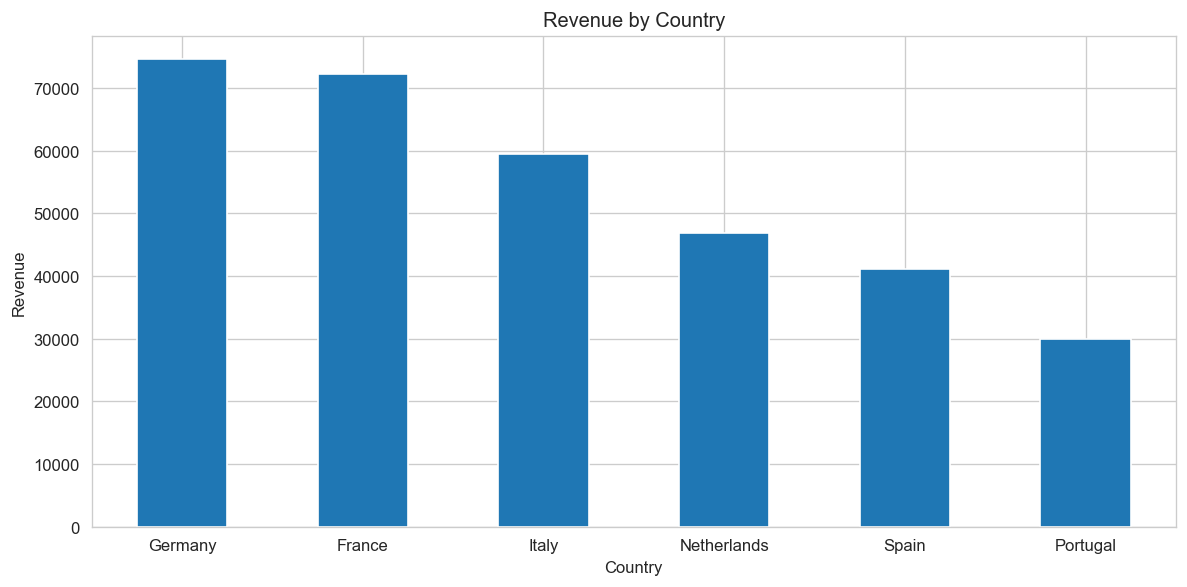

In [36]:
plt.figure(figsize=(10, 5))

country_sales["revenue"].plot(
    kind="bar"
)

plt.title("Revenue by Country")
plt.xlabel("Country")
plt.ylabel("Revenue")

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

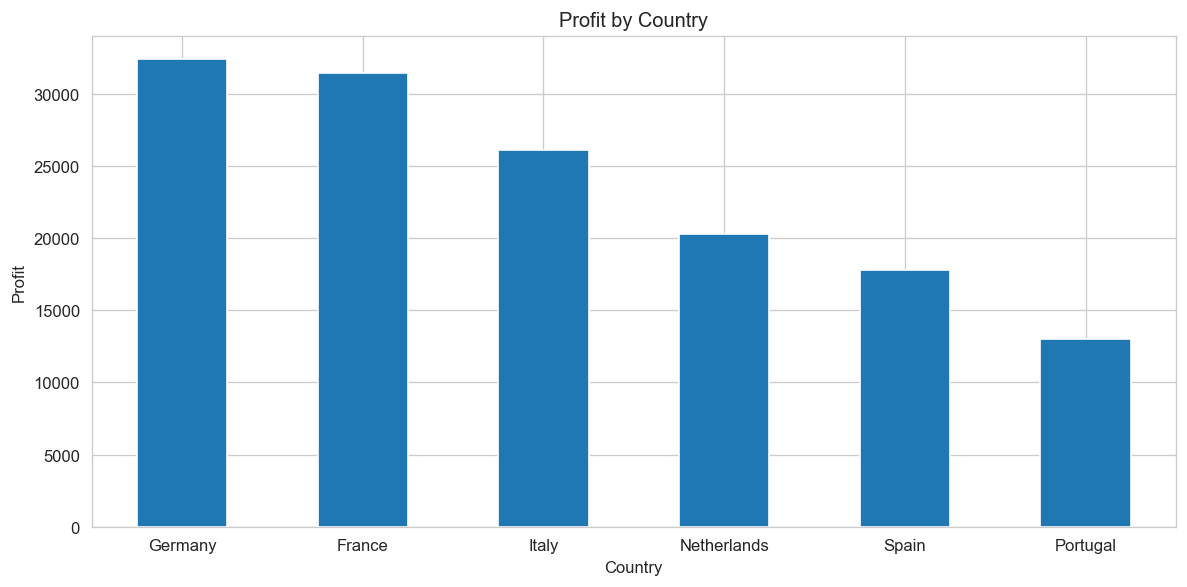

In [37]:
plt.figure(figsize=(10, 5))

country_sales["profit"].plot(
    kind="bar"
)

plt.title("Profit by Country")
plt.xlabel("Country")
plt.ylabel("Profit")

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [38]:
category_sales = (
    eda
    .groupby("category")
    .agg(
        sales_count=("item_id", "count"),
        quantity_sold=("quantity", "sum"),
        revenue=("item_total", "sum"),
        profit=("profit", "sum")
    )
    .sort_values("revenue", ascending=False)
)

In [39]:
category_sales["profit_margin"] = (
    category_sales["profit"]
    / category_sales["revenue"]
    * 100
)

print(category_sales)

           sales_count  quantity_sold   revenue    profit  profit_margin
category                                                                
Shoes              472           1400  70074.00  30473.46      43.487542
T-Shirts           492           1439  69692.78  30782.64      44.169052
Dresses            482           1451  68390.64  29846.75      43.641571
Sleepwear          455           1362  62276.58  26000.55      41.750125
Pants              352           1063  53802.66  24049.89      44.700188


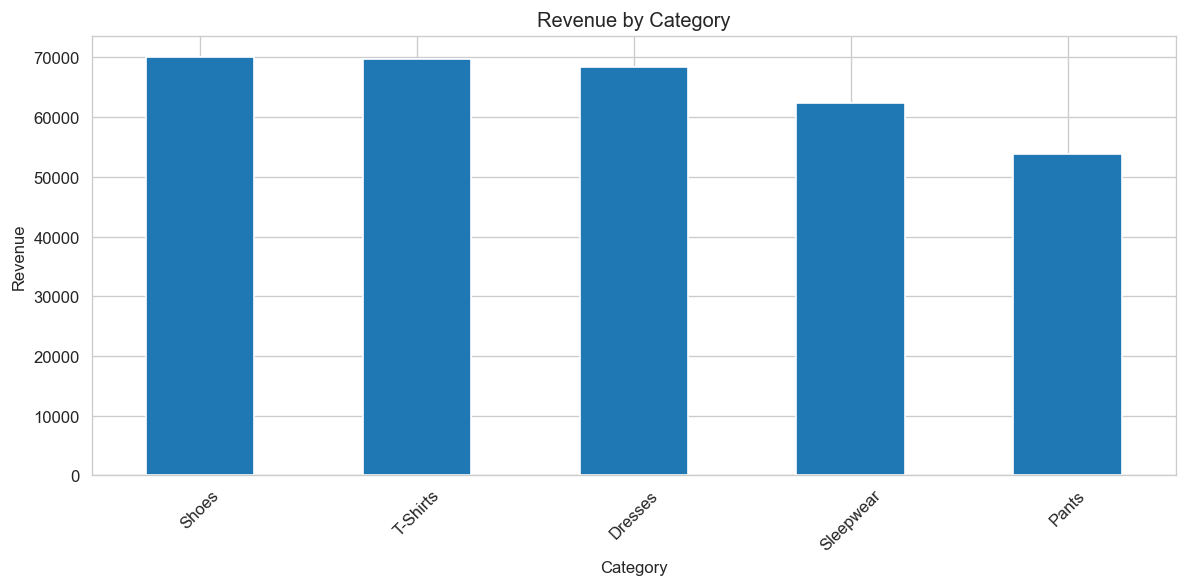

In [40]:
plt.figure(figsize=(10, 5))

category_sales["revenue"].plot(
    kind="bar"
)

plt.title("Revenue by Category")
plt.xlabel("Category")
plt.ylabel("Revenue")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [41]:
channel_sales = (
    eda
    .groupby("channel_sale")
    .agg(
        sales_count=("item_id", "count"),
        quantity_sold=("quantity", "sum"),
        revenue=("item_total", "sum"),
        profit=("profit", "sum")
    )
    .sort_values("revenue", ascending=False)
)

In [42]:
channel_sales["profit_margin"] = (
    channel_sales["profit"]
    / channel_sales["revenue"]
    * 100
)

print(channel_sales)

              sales_count  quantity_sold    revenue    profit  profit_margin
channel_sale                                                                
E-commerce           1170           3507  171675.72  76537.09      44.582361
App Mobile           1083           3208  152560.94  64616.20      42.354354


In [43]:
monthly_sales = (
    eda
    .groupby(["year", "month"])
    .agg(
        sales_count=("item_id", "count"),
        quantity_sold=("quantity", "sum"),
        revenue=("item_total", "sum"),
        profit=("profit", "sum")
    )
    .reset_index()
)


In [44]:
monthly_sales["year_month"] = pd.to_datetime(
    monthly_sales["year"].astype(str)
    + "-"
    + monthly_sales["month"].astype(str)
    + "-01"
)

monthly_sales = monthly_sales.sort_values("year_month")

print(monthly_sales)

   year  month  sales_count  quantity_sold    revenue    profit year_month
0  2025      4          904           2689  133392.44  59171.19 2025-04-01
1  2025      5         1008           3026  141922.21  60372.00 2025-05-01
2  2025      6          341           1000   48922.01  21610.10 2025-06-01


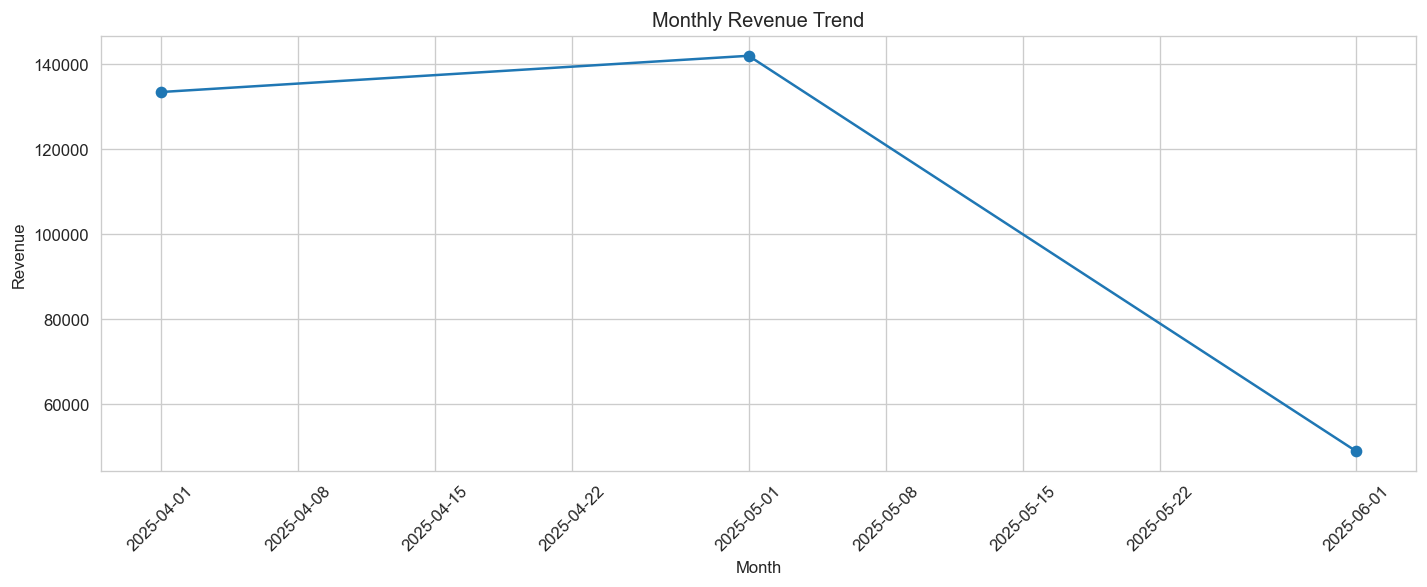

In [45]:
plt.figure(figsize=(12, 5))

plt.plot(
    monthly_sales["year_month"],
    monthly_sales["revenue"],
    marker="o"
)

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

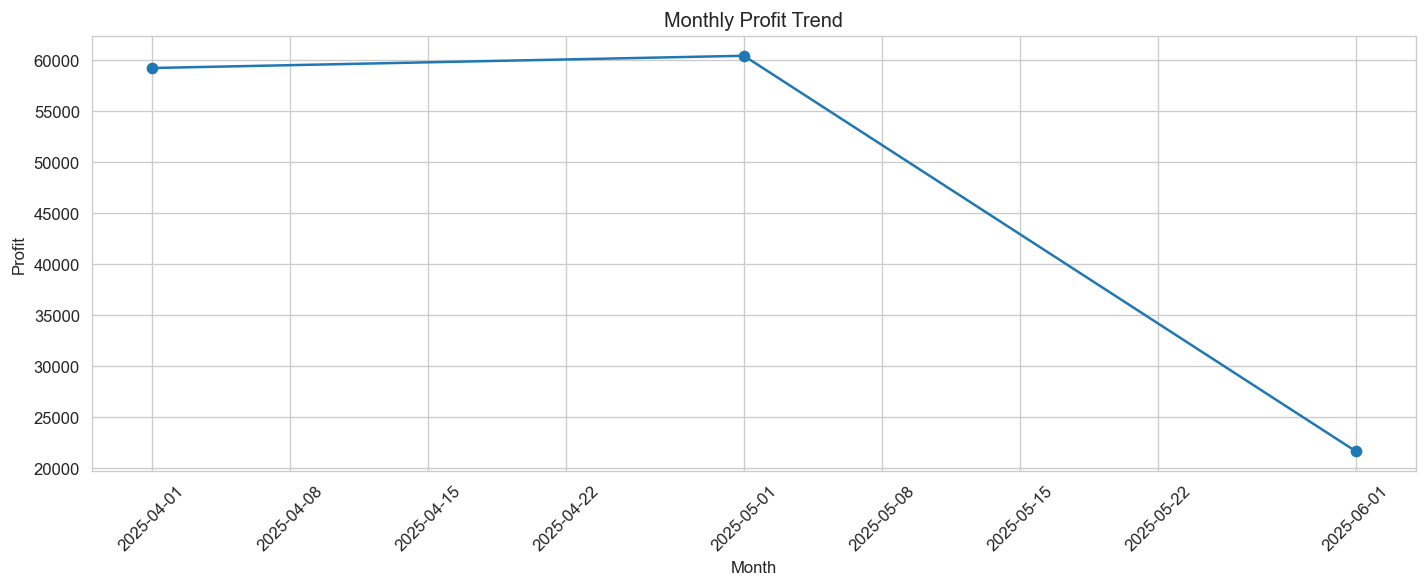

In [46]:
plt.figure(figsize=(12, 5))

plt.plot(
    monthly_sales["year_month"],
    monthly_sales["profit"],
    marker="o"
)

plt.title("Monthly Profit Trend")
plt.xlabel("Month")
plt.ylabel("Profit")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [47]:
print("TOP PRODUCTS BY REVENUE")

product_sales = (
    eda
    .groupby(["product_id", "product_name"])
    .agg(
        sales_count=("item_id", "count"),
        quantity_sold=("quantity", "sum"),
        revenue=("item_total", "sum"),
        profit=("profit", "sum")
    )
    .reset_index()
    .sort_values("revenue", ascending=False)
)
print(product_sales.head())

TOP PRODUCTS BY REVENUE
     product_id                product_name  sales_count  quantity_sold  \
309         310     Relaxed Ribbed Trousers            8             36   
59           60           Modern Cotton Tee            7             25   
115         116  Modern High-Waist Trousers            8             26   
467         469              Dresses Drop 1            8             29   
458         459       Bold High-Waist Dress            8             24   

     revenue   profit  
309  2379.30  1130.10  
59   1919.95   903.70  
115  1907.66   621.18  
467  1858.32   990.35  
458  1804.08  1051.92  


In [48]:
top_revenue_products = (
     product_sales .sort_values(
         "revenue", ascending=False ) .head()
)
print(top_revenue_products)

     product_id                product_name  sales_count  quantity_sold  \
309         310     Relaxed Ribbed Trousers            8             36   
59           60           Modern Cotton Tee            7             25   
115         116  Modern High-Waist Trousers            8             26   
467         469              Dresses Drop 1            8             29   
458         459       Bold High-Waist Dress            8             24   

     revenue   profit  
309  2379.30  1130.10  
59   1919.95   903.70  
115  1907.66   621.18  
467  1858.32   990.35  
458  1804.08  1051.92  


In [49]:
top_profit_products = (
     product_sales .sort_values(
         "profit", ascending=False ) .head()
)
print(top_profit_products)

     product_id             product_name  sales_count  quantity_sold  revenue  \
309         310  Relaxed Ribbed Trousers            8             36  2379.30   
458         459    Bold High-Waist Dress            8             24  1804.08   
467         469           Dresses Drop 1            8             29  1858.32   
59           60        Modern Cotton Tee            7             25  1919.95   
223         224      Relaxed Linen Dress            7             22  1658.80   

      profit  
309  1130.10  
458  1051.92  
467   990.35  
59    903.70  
223   812.24  


In [50]:
top_products = (
    product_sales
    .head(10)
    .sort_values("revenue")
)

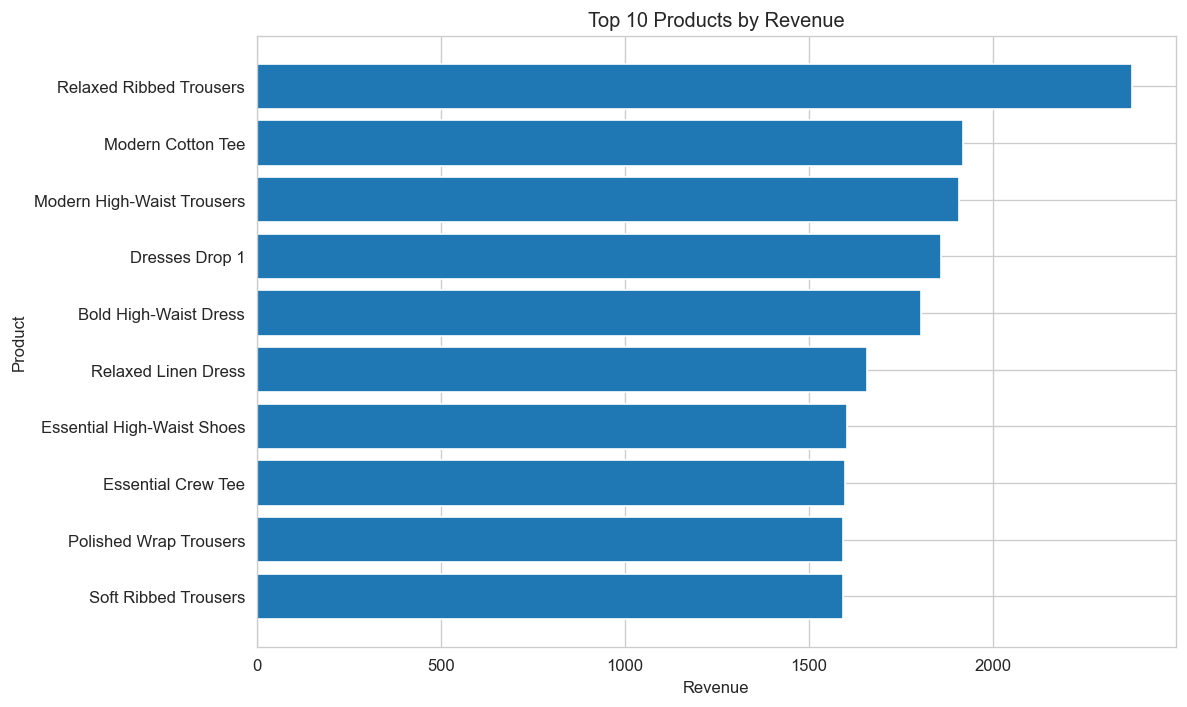

In [51]:
plt.figure(figsize=(10, 6))

plt.barh(
    top_products["product_name"],
    top_products["revenue"]
)

plt.title("Top 10 Products by Revenue")
plt.xlabel("Revenue")
plt.ylabel("Product")

plt.tight_layout()
plt.show()

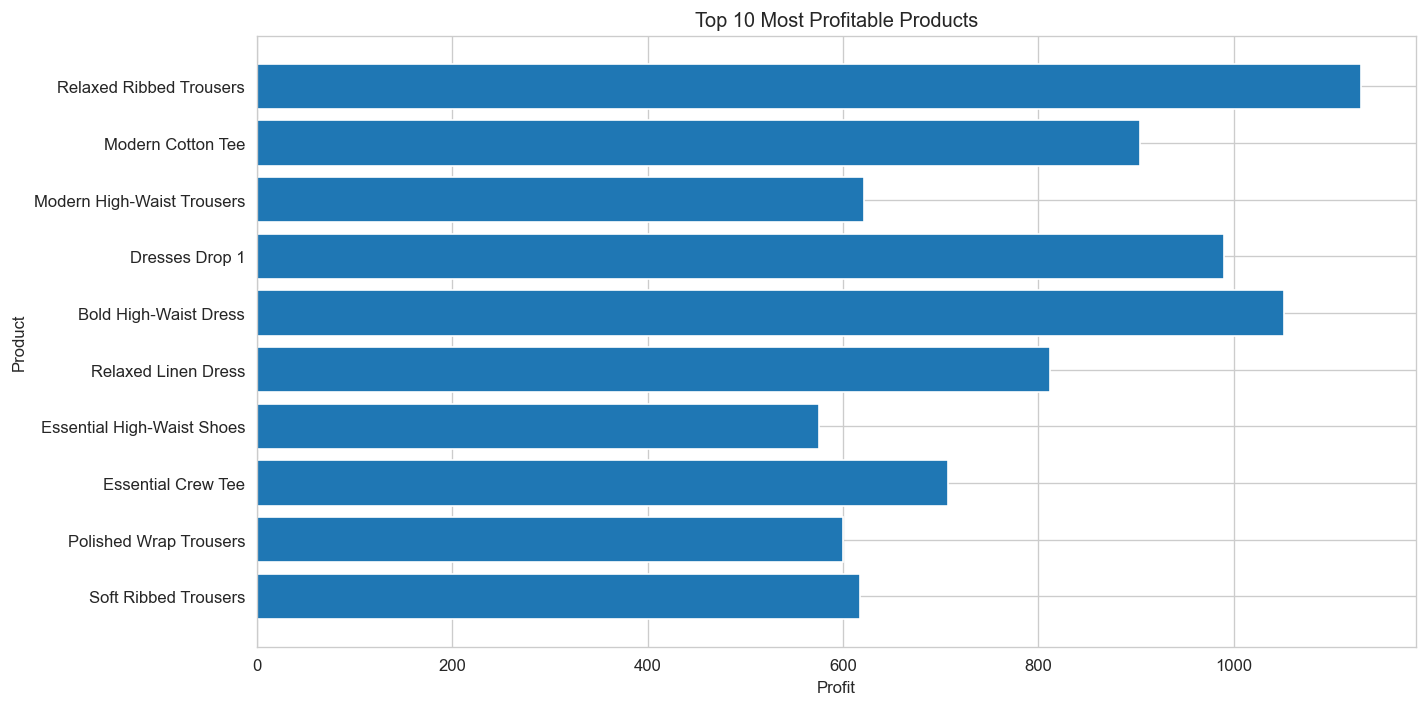

In [52]:
top_profit_products = product_sales.head(10)

plt.figure(figsize=(12, 6))

plt.barh(
    top_profit_products["product_name"],
    top_profit_products["profit"]
)

plt.title("Top 10 Most Profitable Products")
plt.xlabel("Profit")
plt.ylabel("Product")

plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [53]:
category_profit = (
    eda
    .groupby("category")
    .agg(
        revenue=("item_total", "sum"),
        profit=("profit", "sum")
    )
    .sort_values("profit", ascending=False)
)

category_profit["profit_margin"] = (
    category_profit["profit"]
    / category_profit["revenue"]
    * 100
)

print(category_profit)

            revenue    profit  profit_margin
category                                    
T-Shirts   69692.78  30782.64      44.169052
Shoes      70074.00  30473.46      43.487542
Dresses    68390.64  29846.75      43.641571
Sleepwear  62276.58  26000.55      41.750125
Pants      53802.66  24049.89      44.700188


In [54]:
discount_analysis = (
    eda
    .groupby("discount_percent")
    .agg(
        sales_count=("item_id", "count"),
        quantity_sold=("quantity", "sum"),
        revenue=("item_total", "sum"),
        profit=("profit", "sum")
    )
    .sort_index()
)
print(discount_analysis)



                  sales_count  quantity_sold    revenue     profit
discount_percent                                                  
0.00%                    2031           6082  300663.83  134898.76
10.00%                     63            181    7747.96    2908.34
30.00%                    159            452   15824.87    3346.19


In [55]:
age_sales = (
    eda
    .groupby("age_range")
    .agg(
        customers=("customer_id", "nunique"),
        sales=("item_id", "count"),
        quantity=("quantity", "sum"),
        revenue=("item_total", "sum"),
        profit=("profit", "sum")
    )
    .sort_values("revenue", ascending=False)
)

print(age_sales)

           customers  sales  quantity   revenue    profit
age_range                                                
26-35            121    463      1409  69466.31  30319.51
36-45            122    477      1422  68371.81  29736.94
16-25            116    455      1360  65918.37  28499.97
46-55            111    433      1309  62635.41  26850.07
56-65            110    425      1215  57844.76  25746.80


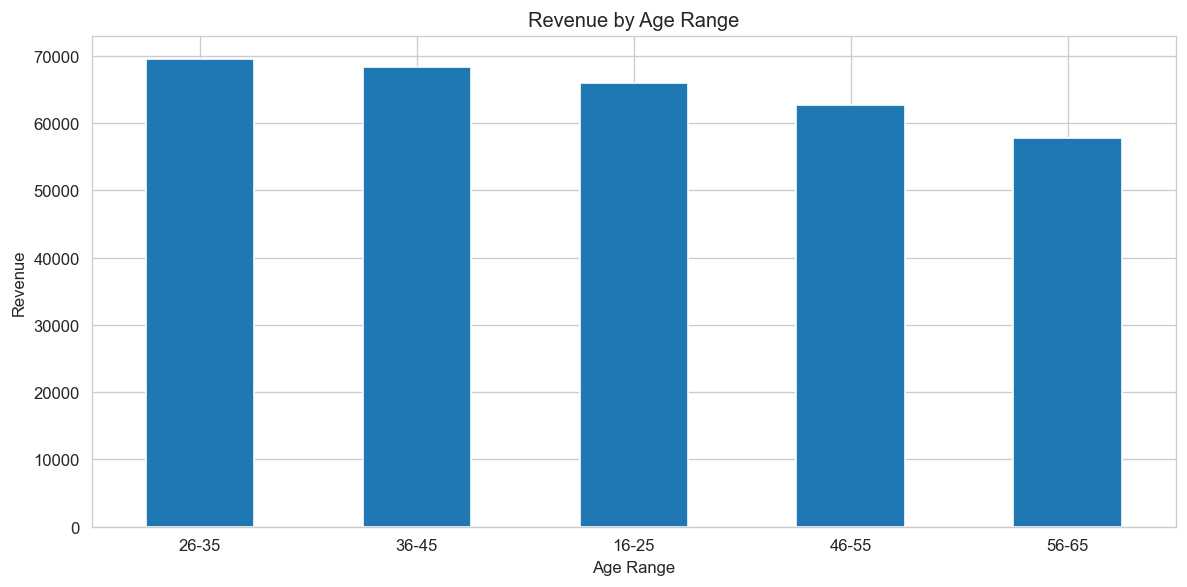

In [56]:
plt.figure(figsize=(10, 5))

age_sales["revenue"].plot(kind="bar")

plt.title("Revenue by Age Range")
plt.xlabel("Age Range")
plt.ylabel("Revenue")

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [57]:
product_comparison = (
    product_sales
    .sort_values("revenue", ascending=False)
    .head(10)
    [["product_name", "quantity_sold", "revenue", "profit"]]
)

print(product_comparison)

                   product_name  quantity_sold  revenue   profit
309     Relaxed Ribbed Trousers             36  2379.30  1130.10
59            Modern Cotton Tee             25  1919.95   903.70
115  Modern High-Waist Trousers             26  1907.66   621.18
467              Dresses Drop 1             29  1858.32   990.35
458       Bold High-Waist Dress             24  1804.08  1051.92
223         Relaxed Linen Dress             22  1658.80   812.24
296  Essential High-Waist Shoes             25  1603.18   575.18
306          Essential Crew Tee             24  1598.19   707.55
238      Polished Wrap Trousers             25  1594.37   600.12
9          Soft Ribbed Trousers             20  1594.00   617.80


In [58]:
print("CUSTOMER ANALYSIS")


customer_sales = (
    eda
    .groupby("customer_id")
    .agg(
        purchase_count=("item_id", "count"),
        quantity_bought=("quantity", "sum"),
        revenue=("item_total", "sum"),
        profit=("profit", "sum"),
        avg_order_value=("item_total", "mean"),
        country=("country_customer", "first"),
        age_range=("age_range", "first"),
        gender=("gender", "first")
    )
    .reset_index()
)

print("\nNumber of customers:", len(customer_sales))

CUSTOMER ANALYSIS

Number of customers: 580


In [59]:
print("TOP 10 CUSTOMERS BY REVENUE")
top_customers = (
    customer_sales
    .sort_values("revenue", ascending=False)
    .head(10)
)

print(top_customers)

TOP 10 CUSTOMERS BY REVENUE
     customer_id  purchase_count  quantity_bought  revenue   profit  \
54            99              18               51  2678.59  1217.39   
508          872              12               42  2221.05   943.13   
133          220              10               40  2180.51   970.60   
470          816              10               36  1921.08   858.68   
151          253               9               30  1882.24   784.58   
166          277              10               35  1825.27   827.67   
447          776              11               32  1822.66   734.75   
116          190              13               41  1722.06   722.87   
321          564               8               31  1702.70   777.04   
258          453               8               27  1665.51   759.90   

     avg_order_value      country age_range  gender  
54        148.810556        Spain     36-45  Female  
508       185.087500  Netherlands     26-35  Female  
133       218.051000      Ge

In [60]:
print("TOP 10 CUSTOMERS BY PROFIT")

top_profit_customers = (
    customer_sales
    .sort_values("profit", ascending=False)
    .head(10)
)

print(top_profit_customers)

TOP 10 CUSTOMERS BY PROFIT
     customer_id  purchase_count  quantity_bought  revenue   profit  \
54            99              18               51  2678.59  1217.39   
133          220              10               40  2180.51   970.60   
508          872              12               42  2221.05   943.13   
198          346              10               31  1660.56   879.73   
470          816              10               36  1921.08   858.68   
166          277              10               35  1825.27   827.67   
151          253               9               30  1882.24   784.58   
321          564               8               31  1702.70   777.04   
258          453               8               27  1665.51   759.90   
447          776              11               32  1822.66   734.75   

     avg_order_value      country age_range  gender  
54        148.810556        Spain     36-45  Female  
133       218.051000      Germany     26-35  Female  
508       185.087500  Netherl

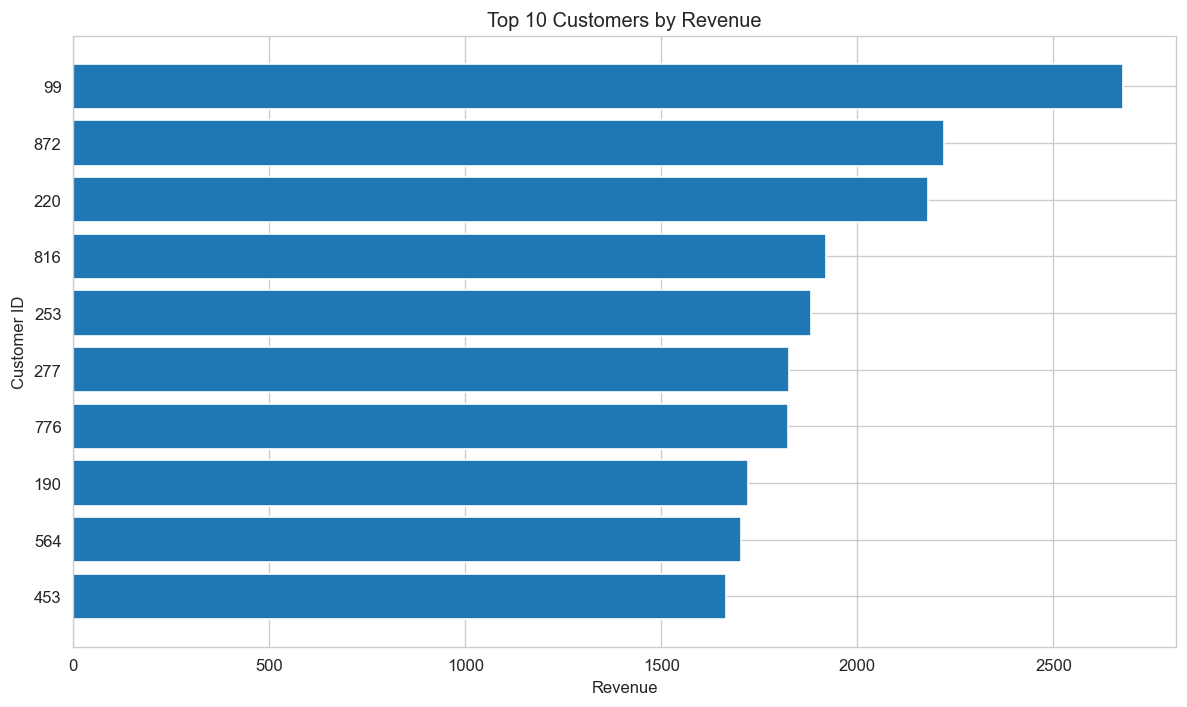

In [61]:
top_customers_plot = (
    top_customers
    .sort_values("revenue")
)

plt.figure(figsize=(10, 6))

plt.barh(
    top_customers_plot["customer_id"].astype(str),
    top_customers_plot["revenue"]
)

plt.title("Top 10 Customers by Revenue")
plt.xlabel("Revenue")
plt.ylabel("Customer ID")

plt.tight_layout()
plt.show()

In [62]:
reference_date = eda["sale_date"].max() + pd.Timedelta(days=1)

In [63]:
print("RFM ANALYSIS")
rfm = (
    eda
    .groupby("customer_id")
    .agg(
        Recency=("sale_date", lambda x: (reference_date - x.max()).days),
        Frequency=("sale_id", "nunique"),
        Monetary=("item_total", "sum")
    )
    .reset_index()
)

print(rfm.head())

RFM ANALYSIS
   customer_id  Recency  Frequency  Monetary
0            1       54          1    663.69
1            2       23          3   1450.65
2            5       27          2    836.54
3            9       24          2    692.80
4           12       58          1    560.00


In [64]:
print("\nRFM Statistics:")
print(rfm[["Recency", "Frequency", "Monetary"]].describe())


RFM Statistics:
          Recency   Frequency     Monetary
count  580.000000  580.000000   580.000000
mean    32.494828    1.560345   559.028724
std     20.320106    0.815320   354.766861
min      1.000000    1.000000    61.090000
25%     18.000000    1.000000   309.792500
50%     30.000000    1.000000   483.545000
75%     51.250000    2.000000   721.985000
max     75.000000    7.000000  2678.590000


In [65]:
rfm["R_score"] = pd.qcut(
    rfm["Recency"],
    4,
    labels=[4, 3, 2, 1]
)

rfm["F_score"] = pd.qcut(
    rfm["Frequency"].rank(method="first"),
    4,
    labels=[1, 2, 3, 4]
)

rfm["M_score"] = pd.qcut(
    rfm["Monetary"],
    4,
    labels=[1, 2, 3, 4]
)

rfm["RFM_score"] = (
    rfm["R_score"].astype(int)
    + rfm["F_score"].astype(int)
    + rfm["M_score"].astype(int)
)

print(rfm.head(10))

   customer_id  Recency  Frequency  Monetary R_score F_score M_score  \
0            1       54          1    663.69       1       1       3   
1            2       23          3   1450.65       3       4       4   
2            5       27          2    836.54       3       3       4   
3            9       24          2    692.80       3       3       3   
4           12       58          1    560.00       1       1       3   
5           14       50          1    167.61       2       1       1   
6           15       25          2    534.08       3       3       3   
7           16       55          1    511.39       1       1       3   
8           17       50          1    458.22       2       1       2   
9           18       22          1    342.14       3       1       2   

   RFM_score  
0          5  
1         11  
2         10  
3          9  
4          5  
5          4  
6          9  
7          5  
8          5  
9          6  


In [66]:
def customer_segment(score):
    if score >= 10:
        return "Champions"
    elif score >= 8:
        return "Loyal Customers"
    elif score >= 6:
        return "Potential Loyalists"
    elif score >= 4:
        return "At Risk"
    else:
        return "Lost Customers"


In [67]:
print("CUSTOMER SEGMENTS")

rfm["segment"] = rfm["RFM_score"].apply(customer_segment)

print(rfm["segment"].value_counts())

CUSTOMER SEGMENTS
segment
Champions              162
At Risk                149
Potential Loyalists    131
Loyal Customers        122
Lost Customers          16
Name: count, dtype: int64


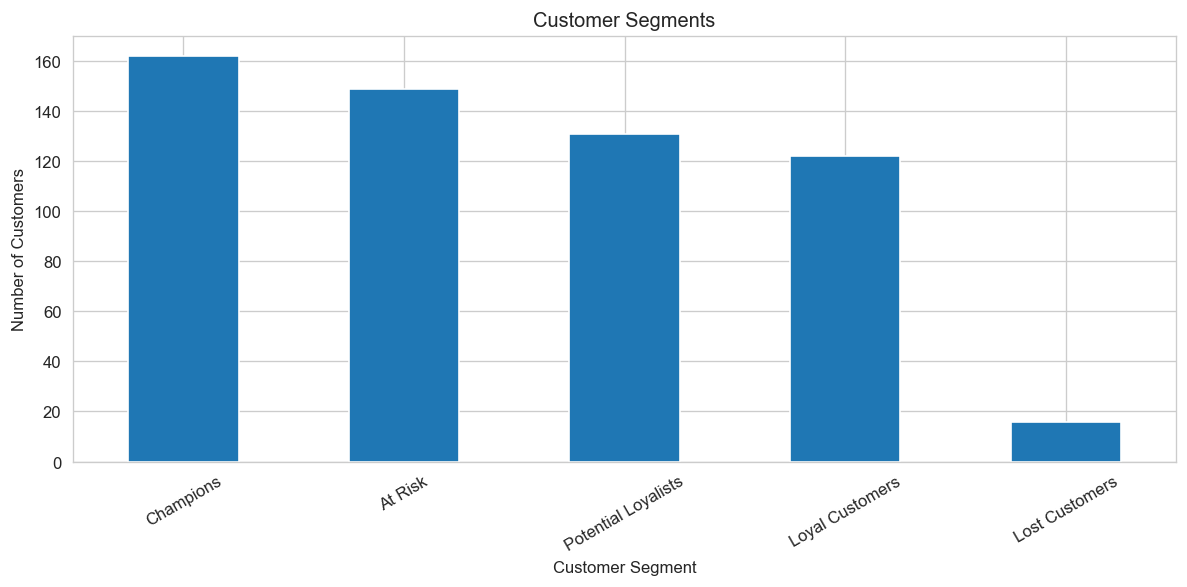

In [68]:
segment_counts = (
    rfm["segment"]
    .value_counts()
)

plt.figure(figsize=(10, 5))

segment_counts.plot(
    kind="bar"
)

plt.title("Customer Segments")
plt.xlabel("Customer Segment")
plt.ylabel("Number of Customers")

plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

In [69]:
campaign_sales = eda.copy()
campaign_sales["campaign_id"] = np.nan

In [70]:
for _, campaign in campaigns.iterrows():
    mask = (
        (campaign_sales["sale_date"] >= campaign["start_date"])
        & (campaign_sales["sale_date"] <= campaign["end_date"])
    )
    campaign_sales.loc[mask, "campaign_id"] = campaign["campaign_id"]

In [71]:
campaign_sales = campaign_sales.merge( 
    campaigns[ [ "campaign_id", "campaign_name", "channel", "discount_type", "discount_value" ] ]
    , on="campaign_id", how="left" )

In [72]:
campaign_sales["campaign_status"] = np.where( campaign_sales["campaign_name"].notna(), "Campaign", "No Campaign" )

In [73]:
print("CAMPAIGN ANALYSIS")

print( "Campaign sales:", (campaign_sales["campaign_status"] == "Campaign").sum() )
print( "Non-campaign sales:", (campaign_sales["campaign_status"] == "No Campaign").sum() )

CAMPAIGN ANALYSIS
Campaign sales: 1585
Non-campaign sales: 668


In [74]:
campaign_performance = (
    campaign_sales[
        campaign_sales["campaign_name"].notna()
    ]
    .groupby(["campaign_id", "campaign_name"])
    .agg(
        sales_count=("item_id", "count"),
        quantity_sold=("quantity", "sum"),
        revenue=("item_total", "sum"),
        profit=("profit", "sum")
    )
    .reset_index()
)

In [75]:
campaign_performance["profit_margin"] = (
    campaign_performance["profit"]
    / campaign_performance["revenue"]
    * 100
)

In [76]:
campaign_performance = campaign_performance.sort_values(
    "revenue",
    ascending=False
)

In [77]:
print("CAMPAIGN PERFORMANCE")


print(campaign_performance)

CAMPAIGN PERFORMANCE
   campaign_id          campaign_name  sales_count  quantity_sold   revenue  \
4          5.0              TIVA Week          545           1648  81400.34   
3          4.0   Mid-Season Clearance          358           1046  44595.74   
6          7.0     Early Summer Deals          229            676  33547.65   
1          2.0       Easter Promotion          116            357  17691.42   
0          1.0      Spring Flash Sale          120            339  16709.61   
2          3.0  Mother's Day Campaign          105            332  15926.13   
5          6.0        June Price Drop          112            324  15374.36   

     profit  profit_margin  
4  37063.19      45.531984  
3  16147.91      36.209535  
6  15117.88      45.063902  
1   7626.35      43.107619  
0   7299.00      43.681450  
2   7160.90      44.963215  
5   6492.22      42.227579  


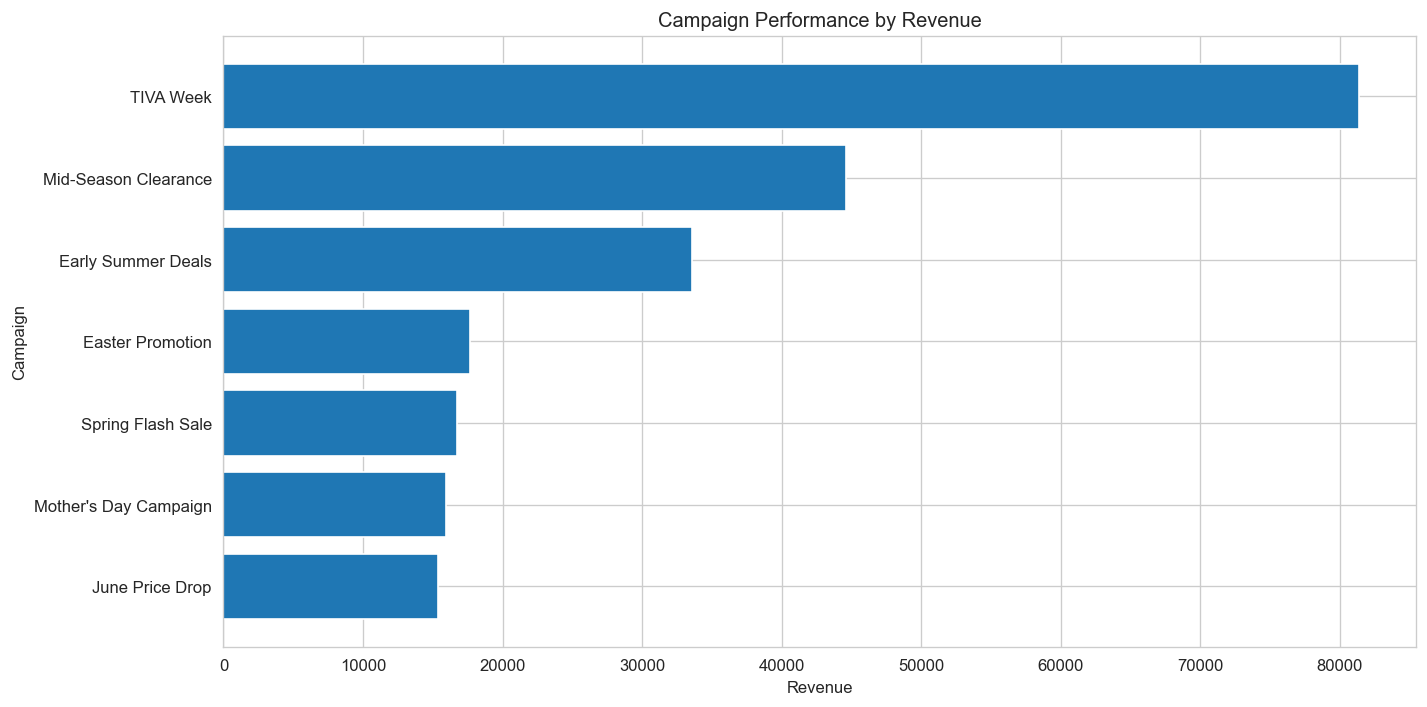

In [78]:
plt.figure(figsize=(12, 6))

plot_campaigns = campaign_performance.sort_values("revenue")

plt.barh(
    plot_campaigns["campaign_name"],
    plot_campaigns["revenue"]
)

plt.title("Campaign Performance by Revenue")
plt.xlabel("Revenue")
plt.ylabel("Campaign")

plt.tight_layout()
plt.show()

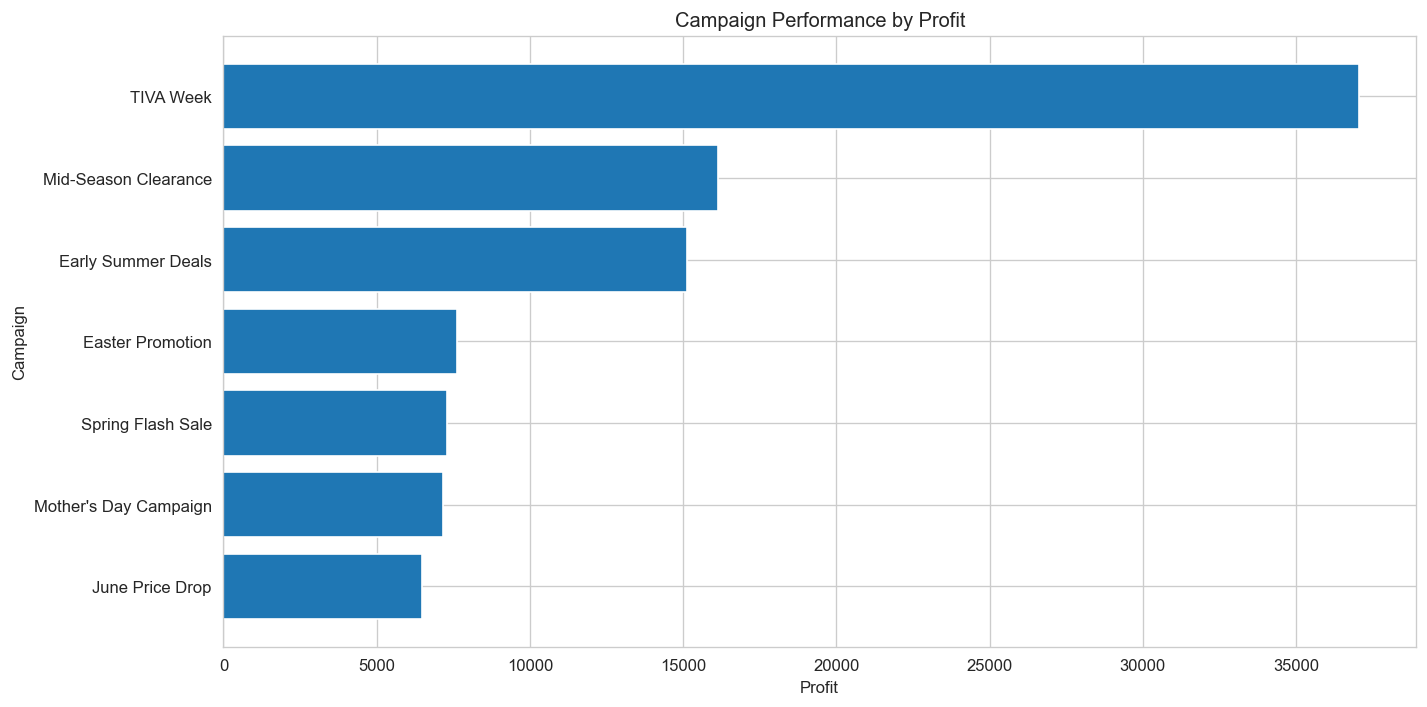

In [79]:
plt.figure(figsize=(12, 6))

plot_campaigns = campaign_performance.sort_values("profit")

plt.barh(
    plot_campaigns["campaign_name"],
    plot_campaigns["profit"]
)

plt.title("Campaign Performance by Profit")
plt.xlabel("Profit")
plt.ylabel("Campaign")

plt.tight_layout()
plt.show()

In [80]:
print("CAMPAIGN VS NO CAMPAIGN")
campaign_sales["campaign_status"] = np.where(
    campaign_sales["campaign_name"].notna(),
    "Campaign",
    "No Campaign"
)


print(campaign_sales["campaign_status"].value_counts())

CAMPAIGN VS NO CAMPAIGN
campaign_status
Campaign       1585
No Campaign     668
Name: count, dtype: int64


In [81]:
campaign_vs_no_campaign = (
    campaign_sales
    .groupby("campaign_status")
    .agg(
        sales_count=("item_id", "count"),
        quantity_sold=("quantity", "sum"),
        revenue=("item_total", "sum"),
        profit=("profit", "sum")
    )
)

In [82]:
print("CAMPAIGN VS NO CAMPAIGN PERFORMANCE")
campaign_vs_no_campaign["profit_margin"] = (
    campaign_vs_no_campaign["profit"]
    / campaign_vs_no_campaign["revenue"]
    * 100
)

print(campaign_vs_no_campaign)

CAMPAIGN VS NO CAMPAIGN PERFORMANCE
                 sales_count  quantity_sold    revenue    profit  \
campaign_status                                                    
Campaign                1585           4722  225245.25  96907.45   
No Campaign              668           1993   98991.41  44245.84   

                 profit_margin  
campaign_status                 
Campaign             43.023083  
No Campaign          44.696646  


In [83]:
campaign_vs_no_campaign["revenue_share"] = (
    campaign_vs_no_campaign["revenue"]
    / campaign_vs_no_campaign["revenue"].sum()
    * 100)

print("\nRevenue Share:")
print(
    campaign_vs_no_campaign[
        ["revenue", "revenue_share", "profit", "profit_margin"]
    ]
)


Revenue Share:
                   revenue  revenue_share    profit  profit_margin
campaign_status                                                   
Campaign         225245.25      69.469396  96907.45      43.023083
No Campaign       98991.41      30.530604  44245.84      44.696646


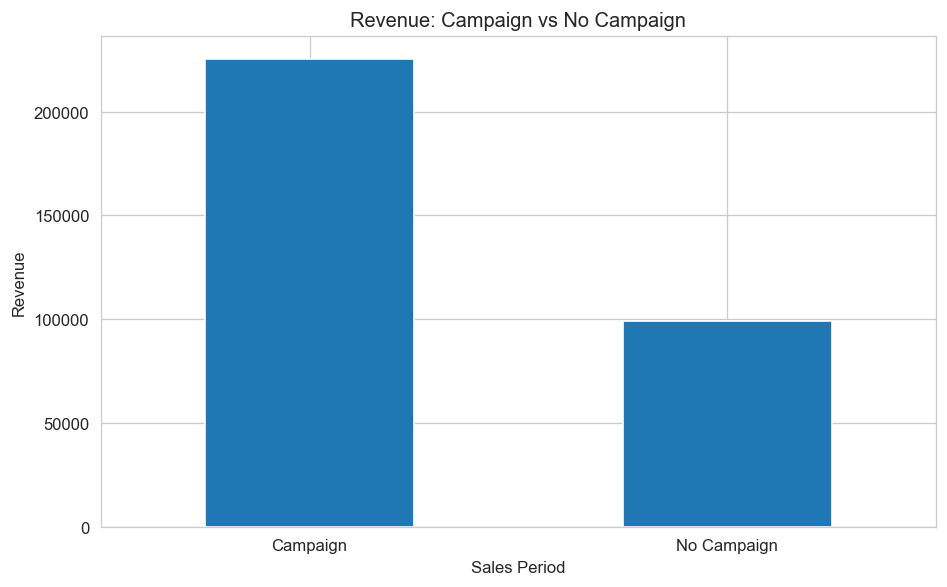

In [84]:
plt.figure(figsize=(8, 5))

campaign_vs_no_campaign["revenue"].plot(
    kind="bar"
)

plt.title("Revenue: Campaign vs No Campaign")
plt.xlabel("Sales Period")
plt.ylabel("Revenue")

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

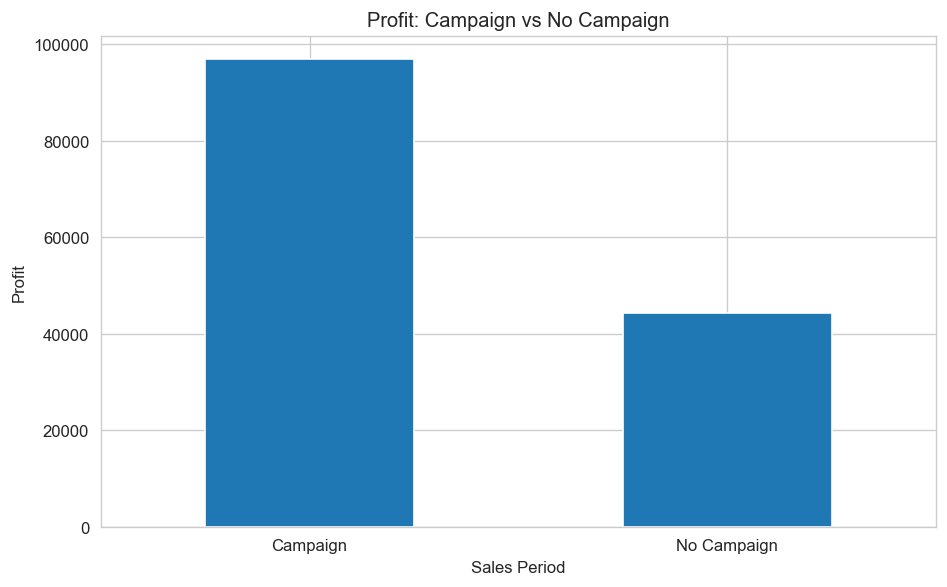

In [85]:
plt.figure(figsize=(8, 5))

campaign_vs_no_campaign["profit"].plot(
    kind="bar"
)

plt.title("Profit: Campaign vs No Campaign")
plt.xlabel("Sales Period")
plt.ylabel("Profit")

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

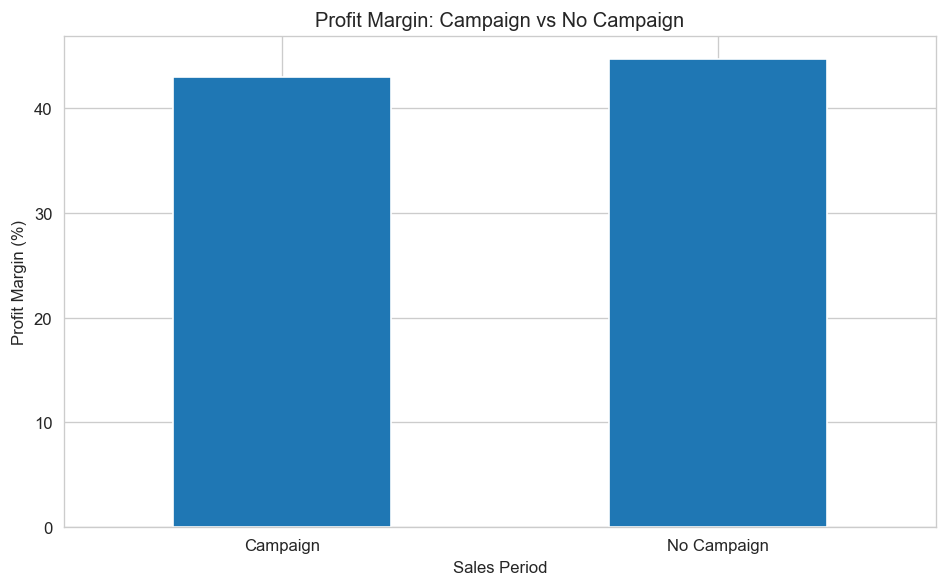

In [86]:
plt.figure(figsize=(8, 5))

campaign_vs_no_campaign["profit_margin"].plot(
    kind="bar"
)

plt.title("Profit Margin: Campaign vs No Campaign")
plt.xlabel("Sales Period")
plt.ylabel("Profit Margin (%)")

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [87]:
print("CAMPAIGN CHANNEL DATA")


print(
    campaign_sales[
        [
            "campaign_id",
            "campaign_name",
            "channel",
            "discount_type",
            "discount_value"
        ]
    ].head()
)

CAMPAIGN CHANNEL DATA
   campaign_id       campaign_name         channel discount_type  \
0          7.0  Early Summer Deals           Email         Fixed   
1          7.0  Early Summer Deals           Email         Fixed   
2          NaN                 NaN             NaN           NaN   
3          6.0     June Price Drop  Website Banner    Percentage   
4          7.0  Early Summer Deals           Email         Fixed   

  discount_value  
0             12  
1             12  
2            NaN  
3         10.00%  
4             12  


In [88]:
campaign_channel_performance = (
    campaign_sales[
        campaign_sales["campaign_name"].notna()
    ]
    .groupby("channel")
    .agg(
        campaigns=("campaign_id", "nunique"),
        sales_count=("item_id", "count"),
        quantity_sold=("quantity", "sum"),
        revenue=("item_total", "sum"),
        profit=("profit", "sum")
    )
    .reset_index()
)


In [89]:

campaign_channel_performance["profit_margin"] = (
    campaign_channel_performance["profit"]
    / campaign_channel_performance["revenue"]
    * 100
)


In [90]:
print("CAMPAIGN PERFORMANCE BY CHANNEL")

campaign_channel_performance = (
    campaign_channel_performance
    .sort_values("revenue", ascending=False)
)

print(campaign_channel_performance)

CAMPAIGN PERFORMANCE BY CHANNEL
          channel  campaigns  sales_count  quantity_sold   revenue    profit  \
2    Social Media          2          661           2005  99091.76  44689.54   
1           Email          3          454           1347  66183.39  29577.78   
0      App Mobile          1          358           1046  44595.74  16147.91   
3  Website Banner          1          112            324  15374.36   6492.22   

   profit_margin  
2      45.099149  
1      44.690639  
0      36.209535  
3      42.227579  


In [91]:
supplier_stock = stock[
    stock["country"].isin(
        SUPPLIER_COUNTRIES
    )
].copy()


In [92]:
print("SUPPLIER STOCK")


print("Supplier stock shape:",supplier_stock.shape)

print("\nSupplier countries:")

print(supplier_stock["country"].value_counts())

SUPPLIER STOCK
Supplier stock shape: (1000, 3)

Supplier countries:
country
France     500
Germany    500
Name: count, dtype: int64


In [93]:
print("SUPPLIER STOCK BY COUNTRY")

supplier_stock_country = (
    supplier_stock
    .groupby("country")
    .agg(
        products=("product_id", "nunique"),
        total_stock=("stock_quantity", "sum"),
        avg_stock=("stock_quantity", "mean"),
        min_stock=("stock_quantity", "min"),
        max_stock=("stock_quantity", "max")
    )
    .sort_values(
        "total_stock",
        ascending=False
    )
)

print(supplier_stock_country)

SUPPLIER STOCK BY COUNTRY
         products  total_stock  avg_stock  min_stock  max_stock
country                                                        
France        500        24136     48.272          1         99
Germany       500          500      1.000          1          1


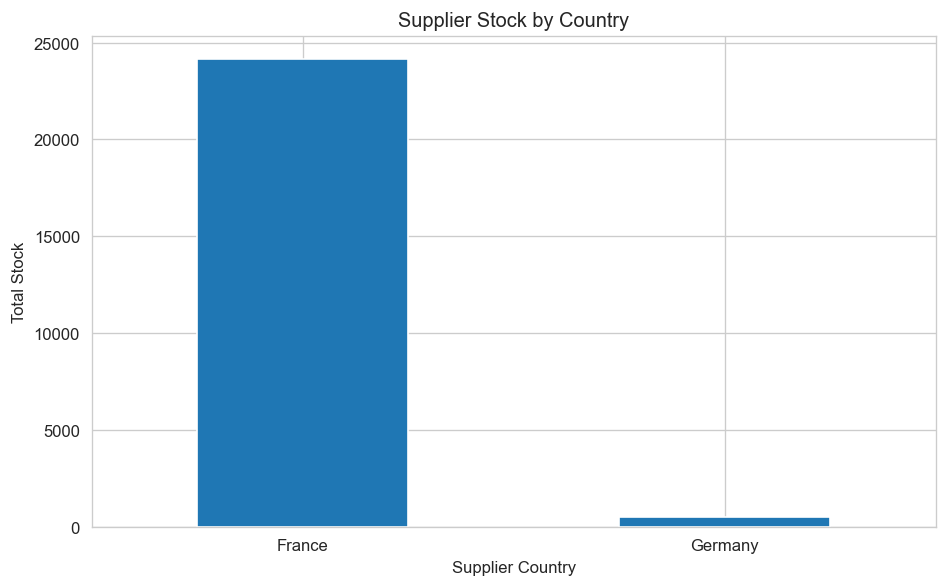

In [94]:
plt.figure(figsize=(8, 5))

supplier_stock_country[
    "total_stock"
].plot(
    kind="bar"
)

plt.title("Supplier Stock by Country")
plt.xlabel("Supplier Country")
plt.ylabel("Total Stock")

plt.xticks(rotation=0)

plt.tight_layout()

plt.show()

In [95]:
product_stock = (
    supplier_stock
    .groupby("product_id")
    .agg(
        total_stock=("stock_quantity", "sum"),
        avg_stock=("stock_quantity", "mean"),
        countries=("country", "nunique")
    )
    .reset_index()
)


In [96]:

product_stock = product_stock.merge(
    products[
        [
            "product_id",
            "product_name"
        ]
    ],
    on="product_id",
    how="left"
)


In [97]:

product_stock = product_stock[
    [
        "product_id",
        "product_name",
        "total_stock",
        "avg_stock",
        "countries"
    ]
]

In [98]:
print("LOW STOCK PRODUCTS")

low_stock_products = (
    product_stock
    .sort_values(
        "total_stock",
        ascending=True
    )
)

print(low_stock_products.head())

LOW STOCK PRODUCTS
     product_id            product_name  total_stock  avg_stock  countries
48           49           Soft Boxy Tee            2        1.0          2
400         401    Elegant Cotton Dress            2        1.0          2
403         404      Elegant Cotton Set            2        1.0          2
15           16    Soft Cotton Trousers            2        1.0          2
156         157  Classic Sleeveless Set            2        1.0          2


In [99]:
supplier_sales_stock = (
    eda[
        eda["country"].isin(
            SUPPLIER_COUNTRIES
        )
    ]
    .groupby(
        ["product_id", "product_name"]
    )
    .agg(
        quantity_sold=("quantity", "sum"),
        revenue=("item_total", "sum"),
        profit=("profit", "sum")
    )
    .reset_index()
)


In [100]:
supplier_sales_stock = (
    supplier_sales_stock
    .merge(
        product_stock[
            [
                "product_id",
                "total_stock"
            ]
        ],
        on="product_id",
        how="left"
    )
)

In [101]:
supplier_sales_stock[
    "sales_to_stock_ratio"
] = np.where(
    supplier_sales_stock["total_stock"] > 0,
    supplier_sales_stock["quantity_sold"]
    /
    supplier_sales_stock["total_stock"],
    np.nan
)


In [102]:
print("HIGH SALES + LOW STOCK PRODUCTS")

high_sales_low_stock = (
    supplier_sales_stock[
        (supplier_sales_stock["quantity_sold"] >= 10)
        &
        (supplier_sales_stock["total_stock"] <= 10)
    ]
    .sort_values(
        "sales_to_stock_ratio",
        ascending=False
    )
)


print(high_sales_low_stock.head())


HIGH SALES + LOW STOCK PRODUCTS
     product_id            product_name  quantity_sold  revenue  profit  \
153         175      Vintage Cotton Tee             13   639.08  259.74   
120         137  Classic Satin Trousers             12   558.24  248.04   
247         280     Essential Linen Tee             10   441.40  159.50   
171         195        Vintage Crew Tee             14   203.62   86.44   
383         434         Bold Ribbed Tee             16   690.24  393.28   

     total_stock  sales_to_stock_ratio  
153            2              6.500000  
120            2              6.000000  
247            2              5.000000  
171            3              4.666667  
383            4              4.000000  


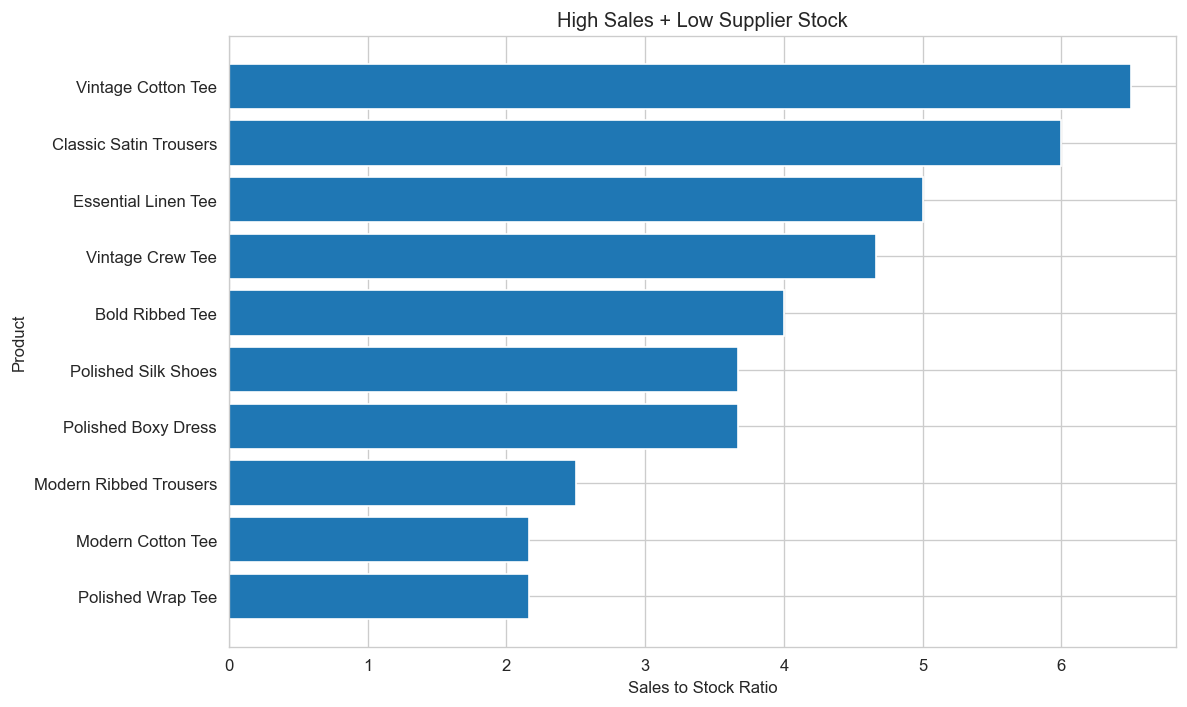

In [103]:
plot_inventory = (
    high_sales_low_stock
    .head(10)
    .sort_values(
        "sales_to_stock_ratio"
    )
)

plt.figure(figsize=(10, 6))

plt.barh(
    plot_inventory["product_name"],
    plot_inventory["sales_to_stock_ratio"]
)

plt.title(
    "High Sales + Low Supplier Stock"
)

plt.xlabel(
    "Sales to Stock Ratio"
)

plt.ylabel("Product")

plt.tight_layout()


In [104]:
print("SALES MARKETS WITHOUT LOCAL STOCK")
sales_without_local_stock = eda[
    eda["country"].isin(
        SALES_ONLY_COUNTRIES
    )
]

sales_only_country_analysis = (
    sales_without_local_stock
    .groupby("country")
    .agg(
        sales_count=("item_id", "count"),
        quantity_sold=("quantity", "sum"),
        revenue=("item_total", "sum"),
        profit=("profit", "sum")
    )
    .sort_values(
        "revenue",
        ascending=False
    )
)

print(sales_only_country_analysis)

SALES MARKETS WITHOUT LOCAL STOCK
             sales_count  quantity_sold   revenue    profit
country                                                    
Italy                415           1230  59458.11  26131.25
Netherlands          326            989  46841.46  20328.14
Spain                276            843  41114.79  17806.27
Portugal             201            605  29930.95  12992.31


In [105]:
print("MISSING SUPPLIER STOCK")

missing_supplier_stock = sales_analysis[
    sales_analysis["country"].isin(
        SUPPLIER_COUNTRIES
    )
    &
    sales_analysis["stock_quantity"].isna()
]

print("MISSING SUPPLIER STOCK")


print("Rows:",len(missing_supplier_stock))

print(
    missing_supplier_stock[
        [
            "product_id",
            "product_name",
            "country",
            "quantity"
        ]
    ]
    .drop_duplicates()
    .head(20)
)

MISSING SUPPLIER STOCK
MISSING SUPPLIER STOCK
Rows: 0
Empty DataFrame
Columns: [product_id, product_name, country, quantity]
Index: []


In [106]:
print("MISSING SUPPLIER STOCK - SALES IMPACT")

missing_supplier_stock_analysis = (
    missing_supplier_stock
    .groupby("country")
    .agg(
        sales_count=("item_id", "count"),
        quantity_sold=("quantity", "sum"),
        revenue=("item_total", "sum"),
        profit=("profit", "sum")
    )
    .sort_values(
        "revenue",
        ascending=False
    )
)

print(missing_supplier_stock_analysis)


MISSING SUPPLIER STOCK - SALES IMPACT
Empty DataFrame
Columns: [sales_count, quantity_sold, revenue, profit]
Index: []


In [107]:
print("KEY BUSINESS INSIGHTS")

best_country = (country_sales["revenue"].idxmax())
best_country_revenue = (country_sales["revenue"].max())

print( f"\nBest Country by Revenue: "f"{best_country}")
print(f"Revenue: "f"{best_country_revenue:,.2f}")

best_category = (category_sales["revenue"].idxmax())
best_category_revenue = (category_sales["revenue"].max())

print(f"\nBest Category by Revenue: "f"{best_category}")
print(f"Revenue: "f"{best_category_revenue:,.2f}")

best_channel = (channel_sales["revenue"].idxmax())
best_channel_revenue = (channel_sales["revenue"].max())

print(f"\nBest Channel by Revenue: "f"{best_channel}")
print(f"Revenue: "f"{best_channel_revenue:,.2f}")

best_month = (monthly_sales.loc[monthly_sales["revenue"].idxmax()])
print(f"\nBest Month: "f"{best_month['year_month'].strftime('%B %Y')}")
print(f"Revenue: "f"{best_month['revenue']:,.2f}")


best_product = product_sales.loc[ product_sales["revenue"].idxmax() ]
print( f"\nBest Product by Revenue: " f"{best_product['product_name']}" )
print( f"Revenue: " f"{best_product['revenue']:,.2f}" )

best_profit_product = product_sales.loc[ product_sales["profit"].idxmax() ]
print( f"\nBest Product by Profit: " f"{best_profit_product['product_name']}" )
print( f"Profit: " f"{best_profit_product['profit']:,.2f}" )

best_age = age_sales["revenue"].idxmax()
print( f"\nBest Age Range by Revenue: {best_age}" )
print( f"Revenue: " f"{age_sales.loc[best_age, 'revenue']:,.2f}" )

best_campaign = campaign_performance.loc[ campaign_performance["revenue"].idxmax() ]

print( f"\nBest Campaign by Revenue: " f"{best_campaign['campaign_name']}" )
print( f"Revenue: " f"{best_campaign['revenue']:,.2f}" )

best_supplier_country = ( supplier_stock_country["total_stock"].idxmax() )
print( f"\nHighest Supplier Stock: " f"{best_supplier_country}" )
print( f"Stock: " f"{supplier_stock_country.loc[best_supplier_country, 'total_stock']:,.0f}" )

KEY BUSINESS INSIGHTS

Best Country by Revenue: Germany
Revenue: 74,590.69

Best Category by Revenue: Shoes
Revenue: 70,074.00

Best Channel by Revenue: E-commerce
Revenue: 171,675.72

Best Month: May 2025
Revenue: 141,922.21

Best Product by Revenue: Relaxed Ribbed Trousers
Revenue: 2,379.30

Best Product by Profit: Relaxed Ribbed Trousers
Profit: 1,130.10

Best Age Range by Revenue: 26-35
Revenue: 69,466.31

Best Campaign by Revenue: TIVA Week
Revenue: 81,400.34

Highest Supplier Stock: France
Stock: 24,136


ML

In [108]:
daily = ( eda .set_index("sale_date") .resample("D") 
.agg(
     revenue=("item_total", "sum"),
      transactions=("item_id", "count") 
      ) 
     .reset_index() .sort_values("sale_date") .reset_index(drop=True) 
)


In [109]:
daily["day_of_week"] = daily["sale_date"].dt.dayofweek
daily["month"] = daily["sale_date"].dt.month
daily["quarter"] = daily["sale_date"].dt.quarter
daily["is_weekend"] = (daily["day_of_week"] >= 5).astype(int)

daily["is_month_start"] = (daily["sale_date"].dt.is_month_start).astype(int)
daily["is_month_end"] = (daily["sale_date"].dt.is_month_end).astype(int)


In [110]:
daily["campaign_active"] = 0

for _, campaign in campaigns.iterrows():

    mask = (
        (daily["sale_date"] >= campaign["start_date"]) &
        (daily["sale_date"] <= campaign["end_date"])
    )

    daily.loc[mask, "campaign_active"] = 1


In [111]:
print("TIME-BASED TRAIN / TEST SPLIT")
split_index = int(len(daily) * 0.80)

train_df = daily.iloc[:split_index].copy()
test_df = daily.iloc[split_index:].copy()

print("Train observations:", len(train_df))
print("Test observations:", len(test_df))

print("Train period:",train_df["sale_date"].min(),"to",train_df["sale_date"].max())

print("Test period:",test_df["sale_date"].min(),"to",test_df["sale_date"].max())

TIME-BASED TRAIN / TEST SPLIT
Train observations: 60
Test observations: 15
Train period: 2025-04-04 00:00:00 to 2025-06-02 00:00:00
Test period: 2025-06-03 00:00:00 to 2025-06-17 00:00:00


In [112]:
calendar_features = [
    "day_of_week",
    "month",
    "quarter",
    "is_weekend",
    "is_month_start",
    "is_month_end",
    "campaign_active"
]


In [113]:
lag_features = [
    "revenue_lag_1",
    "revenue_lag_7",
    "revenue_lag_14",
    "revenue_lag_28"
]

In [114]:
rolling_features = [
    "revenue_rolling_mean_7",
    "revenue_rolling_mean_14",
    "revenue_rolling_mean_28",
    "revenue_rolling_std_7",
    "revenue_rolling_std_14",
    "revenue_rolling_std_28"
]

In [115]:
feature_columns = (
    calendar_features
    + lag_features
    + rolling_features
)

In [116]:
train_features = train_df.copy()

In [117]:
for lag in [1, 7, 14, 28]:
    train_features[f"revenue_lag_{lag}"] = (
        train_features["revenue"].shift(lag)
    )

In [118]:
for window in [7, 14, 28]:
     train_features[ f"revenue_rolling_mean_{window}" ] = ( 
          train_features["revenue"] .shift(1) .rolling(window) .mean()
     )

In [119]:
train_features["revenue_rolling_std_7"] = (
    train_features["revenue"]
    .shift(1)
    .rolling(7)
    .std()
)

train_features["revenue_rolling_std_14"] = (
    train_features["revenue"]
    .shift(1)
    .rolling(14)
    .std()
)

train_features["revenue_rolling_std_28"] = (
    train_features["revenue"]
    .shift(1)
    .rolling(28)
    .std()
)

In [120]:
train_features = ( train_features .dropna() .reset_index(drop=True) )

In [121]:
X_train = train_features[feature_columns]
y_train = train_features["revenue"]

In [122]:
categorical_features = [
    "day_of_week",
    "month",
    "quarter"
]

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numerical_features
        ),
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore"
            ),
            categorical_features
        )
    ]
)

NameError: name 'numerical_features' is not defined

In [ ]:
numerical_features = [
    c
    for c in feature_columns
    if c not in categorical_features
]

In [ ]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numerical_features
        ),
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore"
            ),
            categorical_features
        )
    ]
)

In [ ]:
revenue_models = {

    "Linear Regression":
        LinearRegression(),

    "Random Forest":
        RandomForestRegressor(
            n_estimators=300,
            max_depth=10,
            min_samples_leaf=2,
            random_state=42,
            n_jobs=-1
        ),

    "XGBoost":
        xgb.XGBRegressor(
            n_estimators=300,
            max_depth=3,
            learning_rate=0.05,
            subsample=0.8,
            colsample_bytree=0.8,
            objective="reg:squarederror",
            random_state=42,
            n_jobs=-1
        )
}

In [ ]:
trained_models = {}

for name, model in revenue_models.items():

    pipeline = Pipeline(
        steps=[
            (
                "preprocessor",
                preprocessor
            ),
            (
                "model",
                model
            )
        ]
    )

    pipeline.fit(
        X_train,
        y_train
    )

    trained_models[name] = pipeline


In [ ]:
def recursive_forecast(
    model,
    history_df,
    future_df
):

    history = history_df[
        [
            "sale_date",
            "revenue"
        ]
    ].copy()

    history = (
        history
        .sort_values("sale_date")
        .reset_index(drop=True)
    )

    predictions = []

    for _, future_row in future_df.iterrows():

        current_date = future_row["sale_date"]

        # -----------------------------------------------
        # Calendar features
        # -----------------------------------------------

        day_of_week = current_date.dayofweek
        month = current_date.month
        quarter = current_date.quarter

        is_weekend = int(
            day_of_week >= 5
        )

        is_month_start = int(
            current_date.is_month_start
        )

        is_month_end = int(
            current_date.is_month_end
        )

        # -----------------------------------------------
        # Campaign feature
        # -----------------------------------------------

        campaign_active = 0

        for _, campaign in campaigns.iterrows():

            if (
                current_date >= campaign["start_date"]
                and
                current_date <= campaign["end_date"]
            ):

                campaign_active = 1
                break

        # -----------------------------------------------
        # Historical / predicted revenue
        # -----------------------------------------------

        revenue_values = (
            history["revenue"]
            .tolist()
        )

        # -----------------------------------------------
        # Lag features
        # -----------------------------------------------

        lag_1 = revenue_values[-1]

        lag_7 = revenue_values[-7]

        lag_14 = revenue_values[-14]

        lag_28 = revenue_values[-28]

        # -----------------------------------------------
        # Rolling Mean features
        # -----------------------------------------------

        rolling_mean_7 = np.mean(
            revenue_values[-7:]
        )

        rolling_mean_14 = np.mean(
            revenue_values[-14:]
        )

        rolling_mean_28 = np.mean(
            revenue_values[-28:]
        )

        # -----------------------------------------------
        # Rolling Standard Deviation features
        # -----------------------------------------------

        rolling_std_7 = np.std(
            revenue_values[-7:],
            ddof=1
        )

        rolling_std_14 = np.std(
            revenue_values[-14:],
            ddof=1
        )

        rolling_std_28 = np.std(
            revenue_values[-28:],
            ddof=1
        )

        # -----------------------------------------------
        # Create one-row feature dataframe
        # -----------------------------------------------

        X_future = pd.DataFrame(
            {
                "day_of_week": [
                    day_of_week
                ],

                "month": [
                    month
                ],

                "quarter": [
                    quarter
                ],

                "is_weekend": [
                    is_weekend
                ],

                "is_month_start": [
                    is_month_start
                ],

                "is_month_end": [
                    is_month_end
                ],

                "campaign_active": [
                    campaign_active
                ],

                "revenue_lag_1": [
                    lag_1
                ],

                "revenue_lag_7": [
                    lag_7
                ],

                "revenue_lag_14": [
                    lag_14
                ],

                "revenue_lag_28": [
                    lag_28
                ],

                "revenue_rolling_mean_7": [
                    rolling_mean_7
                ],

                "revenue_rolling_mean_14": [
                    rolling_mean_14
                ],

                "revenue_rolling_mean_28": [
                    rolling_mean_28
                ],

                "revenue_rolling_std_7": [
                    rolling_std_7
                ],

                "revenue_rolling_std_14": [
                    rolling_std_14
                ],

                "revenue_rolling_std_28": [
                    rolling_std_28
                ]
            }
        )

        # -----------------------------------------------
        # Predict revenue
        # -----------------------------------------------

        prediction = model.predict(
            X_future
        )[0]

        predictions.append(
            prediction
        )

        # -----------------------------------------------
        # Add prediction to history
        # for recursive forecasting
        # -----------------------------------------------

        history = pd.concat(
            [
                history,

                pd.DataFrame(
                    {
                        "sale_date": [
                            current_date
                        ],

                        "revenue": [
                            prediction
                        ]
                    }
                )
            ],
            ignore_index=True
        )

    # -----------------------------------------------
    # Return predictions
    # -----------------------------------------------

    return np.array(predictions)

In [ ]:
history_values = ( train_df["revenue"] .tolist() )

baseline_predictions = []

In [ ]:
history_values = train_df["revenue"].tolist()

baseline_predictions = []

for _ in range(len(test_df)):

    prediction = history_values[-1]

    baseline_predictions.append(prediction)

    history_values.append(prediction)

baseline_predictions = np.array(baseline_predictions)

In [ ]:
revenue_results = []
test_predictions = {}

for name, model in trained_models.items():

    predictions = recursive_forecast(
        model=model,
        history_df=train_df,
        future_df=test_df
    )

    mae = mean_absolute_error(
        test_df["revenue"],
        predictions
    )

    rmse = np.sqrt(
        mean_squared_error(
            test_df["revenue"],
            predictions
        )
    )

    r2 = r2_score(
        test_df["revenue"],
        predictions
    )

    revenue_results.append(
        {
            "Model": name,
            "MAE": mae,
            "RMSE": rmse,
            "R2": r2
        }
    )

    test_predictions[name] = predictions

    print("\n" + "-" * 60)
    print(name)

    print(
        f"MAE : {mae:,.2f}"
    )

    print(
        f"RMSE: {rmse:,.2f}"
    )

    print(
        f"R²  : {r2:.4f}"
    )


------------------------------------------------------------
Linear Regression
MAE : 1,998.44
RMSE: 2,614.55
R²  : 0.3235

------------------------------------------------------------
Random Forest
MAE : 1,899.28
RMSE: 2,218.32
R²  : 0.5130

------------------------------------------------------------
XGBoost
MAE : 1,908.70
RMSE: 2,558.39
R²  : 0.3523


In [ ]:
baseline_mae = mean_absolute_error(
    test_df["revenue"],
    baseline_predictions
)

baseline_rmse = np.sqrt(
    mean_squared_error(
        test_df["revenue"],
        baseline_predictions
    )
)

baseline_r2 = r2_score(
    test_df["revenue"],
    baseline_predictions
)

In [ ]:
print("BASELINE")

print(f"MAE : {baseline_mae:,.2f}")

print(f"RMSE: {baseline_rmse:,.2f}")

print(f"R²  : {baseline_r2:.4f}")

BASELINE
MAE : 3,261.47
RMSE: 4,554.36
R²  : -1.0527


In [ ]:
print("REVENUE MODEL COMPARISON")
revenue_results_df = (
    pd.DataFrame(
        revenue_results
    )
    .sort_values(
        "MAE",
        ascending=True
    )
    .reset_index(drop=True)
)

print(revenue_results_df)

REVENUE MODEL COMPARISON
               Model          MAE         RMSE        R2
0      Random Forest  1899.284395  2218.322984  0.513019
1            XGBoost  1908.703134  2558.394395  0.352265
2  Linear Regression  1998.437582  2614.553173  0.323516


In [ ]:
best_model_name = (
    revenue_results_df
    .iloc[0]["Model"]
)

best_model = (
    trained_models[
        best_model_name
    ]
)

best_predictions = (
    test_predictions[
        best_model_name
    ]
)

best_row = (
    revenue_results_df
    .iloc[0]
)

In [ ]:
if len(revenue_results_df) > 0:
    best_row = revenue_results_df.iloc[0]
else:
    print("No models were trained successfully!")
    best_row = None

In [ ]:
print("BEST MODEL")

print("Best Model:",best_model_name)

print(f"MAE : {best_row['MAE']:,.2f}")

print(f"RMSE: {best_row['RMSE']:,.2f}")

print(f"R²  : {best_row['R2']:.4f}")

BEST MODEL
Best Model: Random Forest
MAE : 1,899.28
RMSE: 2,218.32
R²  : 0.5130


In [ ]:
if best_row["MAE"] < baseline_mae:

    improvement = (
        1 -
        best_row["MAE"]
        /
        baseline_mae
    ) * 100

    print(
        f"Model improves MAE by "
        f"{improvement:.2f}%"
    )

else:

    deterioration = (
        best_row["MAE"]
        /
        baseline_mae
        - 1
    ) * 100

    print(
        f"Model is {deterioration:.2f}% "
        f"worse than baseline."
    )

Model improves MAE by 41.77%


In [ ]:
if best_model_name in [
    "Random Forest",
    "XGBoost"
]:

    fitted_preprocessor = (
        best_model
        .named_steps[
            "preprocessor"
        ]
    )

    fitted_model = (
        best_model
        .named_steps[
            "model"
        ]
    )

    feature_names = (
        fitted_preprocessor
        .get_feature_names_out()
    )

    importances = (
        fitted_model
        .feature_importances_
    )

    feature_importance = (
        pd.DataFrame(
            {
                "Feature":
                    feature_names,

                "Importance":
                    importances
            }
        )
        .sort_values(
            "Importance",
            ascending=False
        )
        .reset_index(drop=True)
    )
elif best_model_name == "Linear Regression":
    fitted_preprocessor = best_model.named_steps["preprocessor"]
    fitted_model = best_model.named_steps["model"]
    feature_names = fitted_preprocessor.get_feature_names_out()
    coefficients = fitted_model.coef_
    
    feature_importance = pd.DataFrame({
        "Feature": feature_names,
        "Importance": np.abs(coefficients)
    }).sort_values("Importance", ascending=False)

In [ ]:
print("TOP FEATURES")

print(feature_importance.head(20))

top_features = (
    feature_importance
    .head(15)
    .sort_values(
        "Importance"
    )
)

TOP FEATURES
                         Feature    Importance
0   num__revenue_rolling_mean_28  4.346652e-01
1    num__revenue_rolling_std_28  2.230606e-01
2             num__revenue_lag_1  2.023584e-01
3            num__revenue_lag_14  4.886543e-02
4    num__revenue_rolling_std_14  3.156671e-02
5     num__revenue_rolling_std_7  2.807261e-02
6            num__revenue_lag_28  8.885630e-03
7    num__revenue_rolling_mean_7  7.134899e-03
8             num__revenue_lag_7  5.940579e-03
9   num__revenue_rolling_mean_14  3.719935e-03
10            cat__day_of_week_6  1.761681e-03
11            cat__day_of_week_0  1.653914e-03
12            cat__day_of_week_4  8.497841e-04
13            cat__day_of_week_5  5.310952e-04
14               num__is_weekend  4.431253e-04
15            cat__day_of_week_3  2.664613e-04
16            cat__day_of_week_2  1.383604e-04
17            cat__day_of_week_1  8.557959e-05
18                  cat__month_6  1.270758e-18
19          num__campaign_active  0.000000e+00


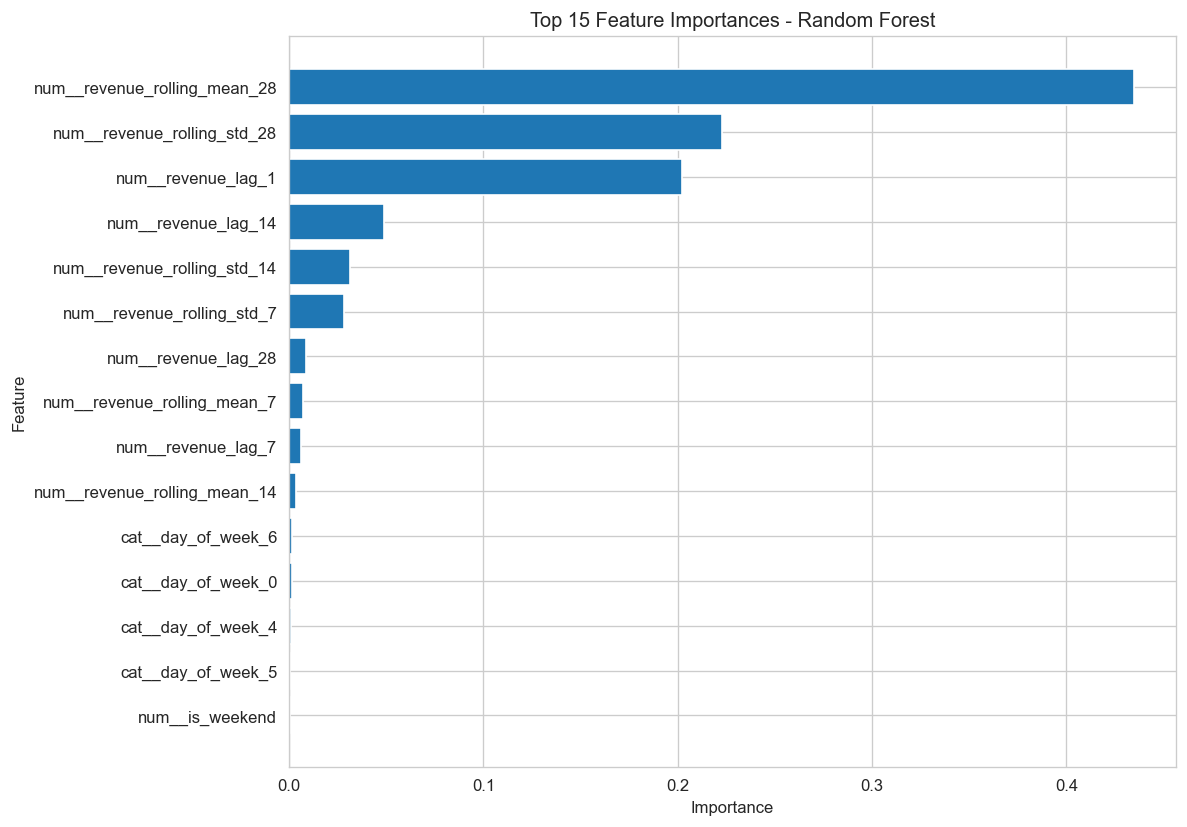

In [ ]:
plt.figure(figsize=(10, 7))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.title(
    f"Top 15 Feature Importances - "
    f"{best_model_name}"
)
plt.xlabel("Importance")

plt.ylabel("Feature")

plt.tight_layout()
plt.show()

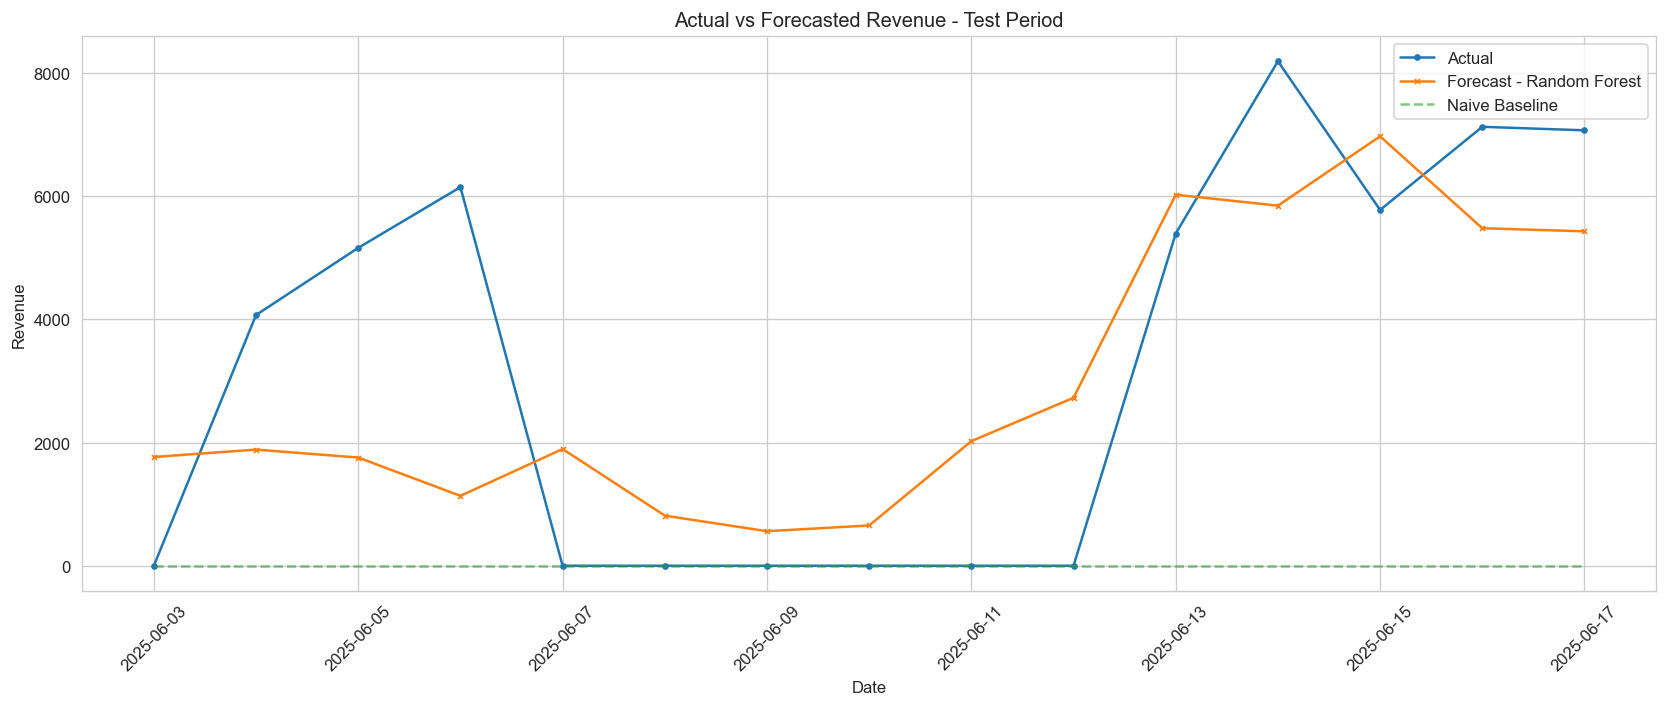

In [ ]:
plt.figure(
    figsize=(14, 6)
)

plt.plot(
    test_df["sale_date"],
    test_df["revenue"],
    label="Actual",
    marker="o",
    markersize=3
)

plt.plot(
    test_df["sale_date"],
    best_predictions,
    label=f"Forecast - {best_model_name}",
    marker="x",
    markersize=3
)

plt.plot(
    test_df["sale_date"],
    baseline_predictions,
    label="Naive Baseline",
    linestyle="--",
    alpha=0.6
)

plt.title(
    "Actual vs Forecasted Revenue - Test Period"
)

plt.xlabel(
    "Date"
)

plt.ylabel(
    "Revenue"
)

plt.legend()

plt.xticks(
    rotation=45
)

plt.tight_layout()

plt.show()

In [ ]:
print("FINAL PROJECT SUMMARY")
print( "\nBUSINESS ANALYSIS" )

print( "Total transactions:", len(eda) )
print( "Total quantity sold:", eda["quantity"].sum() )
print( "Total revenue:", f"{eda['item_total'].sum():,.2f}" )
print( "Total profit:", f"{eda['profit'].sum():,.2f}" )
print( "Number of customers:", eda["customer_id"].nunique() )
print( "Number of products:", eda["product_id"].nunique() )
print( "Supplier countries:", ", ".join(SUPPLIER_COUNTRIES) )
print( "Sales-only countries:", ", ".join(SALES_ONLY_COUNTRIES) )
print( "Campaign sales:", ( campaign_sales["campaign_status"] == "Campaign" ).sum() )
print( "Non-campaign sales:", ( campaign_sales["campaign_status"] == "No Campaign" ).sum() )

print( "\nCUSTOMER SEGMENTATION" )
print( "RFM segments:", rfm["segment"].nunique() )

print( "Segment distribution:" )
print( rfm["segment"].value_counts() )

print( "\nREVENUE FORECASTING" )
print( "Best model:", best_model_name )
print( f"Test MAE: " f"{best_row['MAE']:,.2f}" )
print( f"Test RMSE: " f"{best_row['RMSE']:,.2f}" )
print( f"Test R²: " f"{best_row['R2']:.4f}" )
print( f"Naive MAE: " f"{baseline_mae:,.2f}" )
print( f"Naive RMSE: " f"{baseline_rmse:,.2f}" )
print( f"Naive R²: " f"{baseline_r2:.4f}" )


FINAL PROJECT SUMMARY

BUSINESS ANALYSIS
Total transactions: 2253
Total quantity sold: 6715
Total revenue: 324,236.66
Total profit: 141,153.29
Number of customers: 580
Number of products: 499
Supplier countries: France, Germany
Sales-only countries: Italy, Netherlands, Spain, Portugal
Campaign sales: 1585
Non-campaign sales: 668

CUSTOMER SEGMENTATION
RFM segments: 5
Segment distribution:
segment
Champions              162
At Risk                149
Potential Loyalists    131
Loyal Customers        122
Lost Customers          16
Name: count, dtype: int64

REVENUE FORECASTING
Best model: Random Forest
Test MAE: 1,899.28
Test RMSE: 2,218.32
Test R²: 0.5130
Naive MAE: 3,261.47
Naive RMSE: 4,554.36
Naive R²: -1.0527


In [ ]:
print("\nCustomer Segmentation ""(RFM):")
print(f"RFM Segments: "f"{rfm['segment'].nunique()}")
print(f"Total Customers: "f"{len(rfm):,}")
print("\nSegment Distribution:")
print(rfm["segment"].value_counts())



Customer Segmentation (RFM):
RFM Segments: 5
Total Customers: 580

Segment Distribution:
segment
Champions              162
At Risk                149
Potential Loyalists    131
Loyal Customers        122
Lost Customers          16
Name: count, dtype: int64
